Matriz de covarianza calculada: (100, 100)
Rango de valores de covarianza: 0.0013 a 11.0000


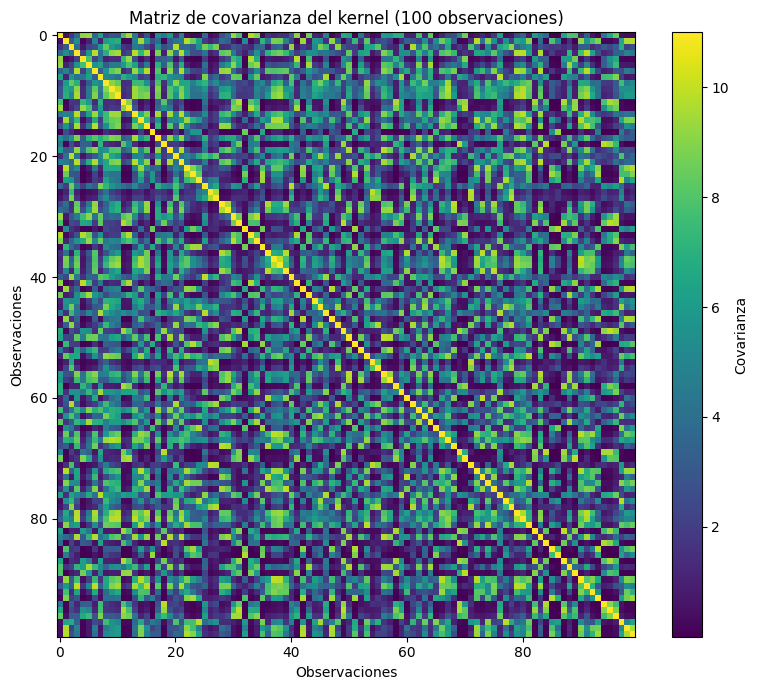

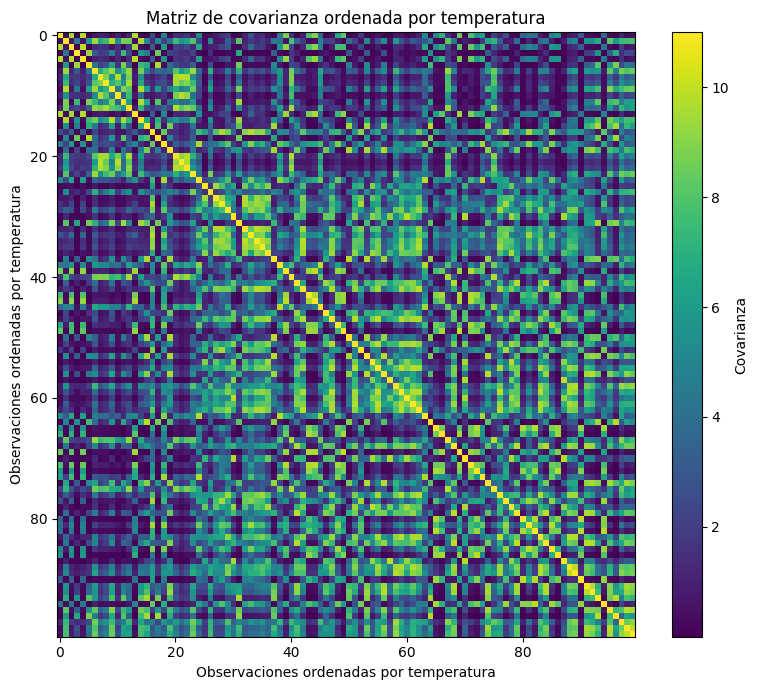

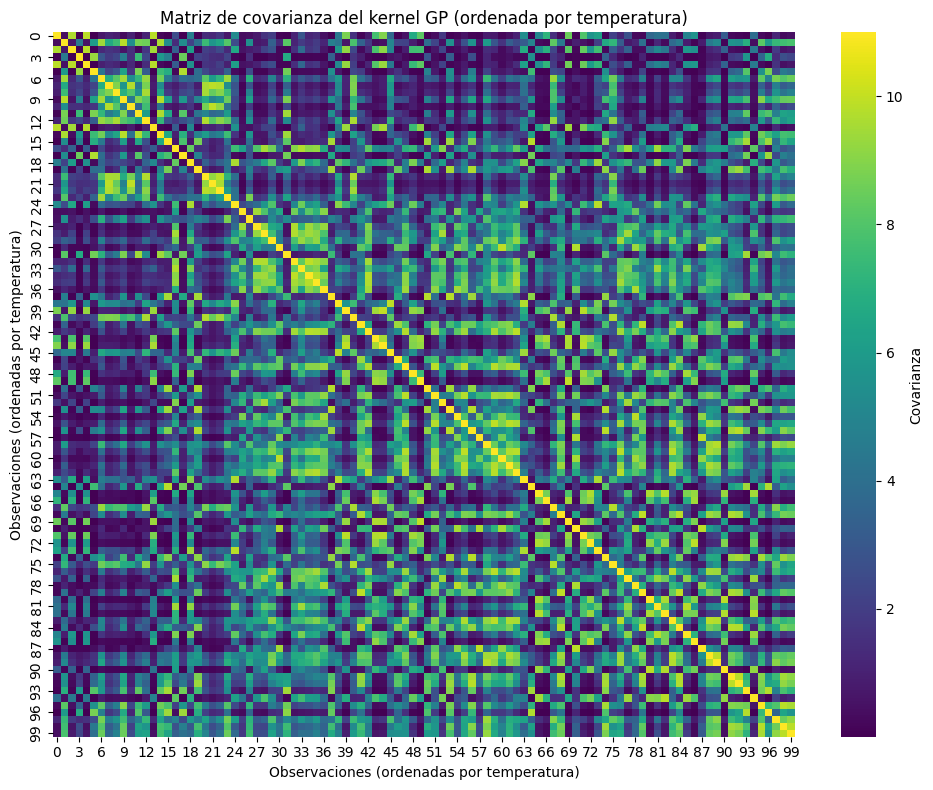


INTERPRETACIÓN DE LA MATRIZ DE COVARIANZA

Covarianza media en la diagonal (misma observación): 11.0000
Covarianza media fuera de la diagonal (diferentes observaciones): 3.6027
Relación diag/off-diag: 3.05
La matriz muestra una fuerte estructura de covarianza.
   Las observaciones similares tienen alta covarianza (bloques claros en la diagonal).


In [ ]:
# ============================================
# MATRIZ DE COVARIANZA (KERNEL) PARA TUS DATOS
# ============================================

# 1. Tomar una muestra de los datos para no saturar la gráfica
# (la matriz completa de 271x271 es manejable, pero para visualizar mejor usamos una submuestra)
n_muestra = min(100, len(X_train_sc))  # Usamos 100 puntos para una visualización clara
rng = np.random.default_rng(42)
idx_muestra = rng.choice(len(X_train_sc), size=n_muestra, replace=False)

# 2. Extraer la submuestra
X_muestra = X_train_sc[idx_muestra]
y_muestra = y_train[idx_muestra]

# 3. Calcular la matriz de covarianza usando el kernel optimizado
# (usa el mejor modelo que ajustaste, por ejemplo modelo_mejor)
K_muestra = modelo_mejor.kernel_(X_muestra)

print(f"Matriz de covarianza calculada: {K_muestra.shape}")
print(f"Rango de valores de covarianza: {K_muestra.min():.4f} a {K_muestra.max():.4f}")

# ============================================
# GRAFICO 1: MATRIZ DE COVARIANZA SIN ORDENAR
# ============================================
plt.figure(figsize=(8, 7))
plt.imshow(K_muestra, aspect='auto', cmap='viridis')
plt.colorbar(label='Covarianza')
plt.xlabel('Observaciones')
plt.ylabel('Observaciones')
plt.title(f'Matriz de covarianza del kernel ({n_muestra} observaciones)')
plt.tight_layout()
plt.savefig("Matriz_Covarianza_GP.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# GRAFICO 2: MATRIZ DE COVARIANZA ORDENADA POR TEMPERATURA
# ============================================
# Ordenar por temperatura (de menor a mayor)
orden_temp = np.argsort(y_muestra)
K_ordenada = K_muestra[orden_temp][:, orden_temp]

plt.figure(figsize=(8, 7))
plt.imshow(K_ordenada, aspect='auto', cmap='viridis')
plt.colorbar(label='Covarianza')
plt.xlabel('Observaciones ordenadas por temperatura')
plt.ylabel('Observaciones ordenadas por temperatura')
plt.title('Matriz de covarianza ordenada por temperatura')
plt.tight_layout()
plt.savefig("Matriz_Covarianza_GP_Ordenada.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# GRAFICO 3: HEATMAP CON SEABORN (MÁS DETALLADO)
# ============================================
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(K_ordenada, cmap='viridis', cbar_kws={'label': 'Covarianza'})
ax.set_title('Matriz de covarianza del kernel GP (ordenada por temperatura)')
ax.set_xlabel('Observaciones (ordenadas por temperatura)')
ax.set_ylabel('Observaciones (ordenadas por temperatura)')
plt.tight_layout()
plt.savefig("Matriz_Covarianza_Heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# INTERPRETACIÓN DE LA MATRIZ
# ============================================
print("\n" + "="*60)
print("INTERPRETACIÓN DE LA MATRIZ DE COVARIANZA")
print("="*60)

# Covarianza media dentro de la diagonal vs fuera de la diagonal
diag_mean = np.mean(np.diag(K_muestra))
off_diag_mean = np.mean(K_muestra[np.triu_indices_from(K_muestra, k=1)])

print(f"\nCovarianza media en la diagonal (misma observación): {diag_mean:.4f}")
print(f"Covarianza media fuera de la diagonal (diferentes observaciones): {off_diag_mean:.4f}")
print(f"Relación diag/off-diag: {diag_mean / off_diag_mean:.2f}")

if diag_mean > off_diag_mean * 2:
    print("La matriz muestra una fuerte estructura de covarianza.")
    print("   Las observaciones similares tienen alta covarianza (bloques claros en la diagonal).")
else:
    print("La covarianza fuera de la diagonal es relativamente alta.")
    print("   Puede indicar que el kernel no está capturando bien la estructura espacial.")

Matriz de covarianza: (100, 100)
Matriz triangular inferior (L): (100, 100)


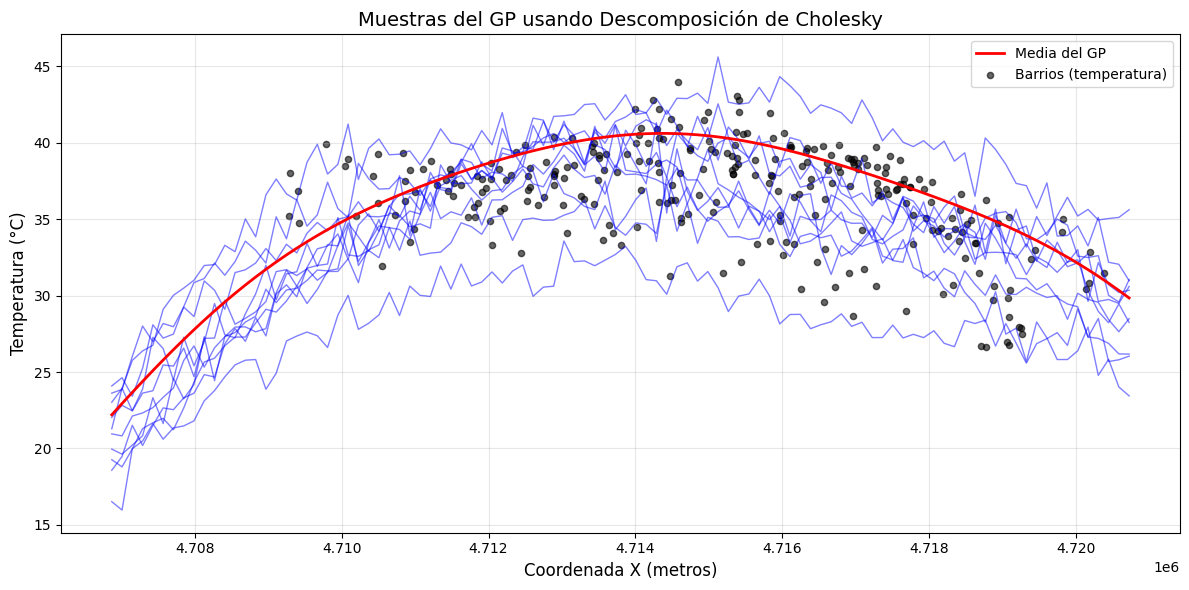

Gráfico de muestras usando Cholesky guardado.


In [ ]:
# ============================================
# DESCOMPOSICIÓN DE CHOLESKY PARA MUESTREO DE FUNCIONES
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky

# 1. Tomar una muestra de puntos para visualizar
n_puntos_muestra = 100
x_vals = np.linspace(xmin, xmax, n_puntos_muestra)
y_vals = np.ones_like(x_vals) * latitud_media

# Crear la matriz de entrada para el GP (con densidad media)
densidad_media = zonas_urbano['densidad_arboles'].mean()
X_nuevos = np.column_stack([x_vals, y_vals, np.ones(n_puntos_muestra) * densidad_media])
X_nuevos_sc = scaler.transform(X_nuevos)

# 2. Calcular la media y la matriz de covarianza en los nuevos puntos
y_mean, _ = modelo_mejor.predict(X_nuevos_sc, return_std=True)
K_nuevos = modelo_mejor.kernel_(X_nuevos_sc)

# 3. Aplicar la descomposición de Cholesky
# Añadir un pequeño ruido a la diagonal para estabilidad numérica
K_nuevos = K_nuevos + 1e-6 * np.eye(n_puntos_muestra)
L = cholesky(K_nuevos, lower=True)  # Descomposición de Cholesky

print(f"Matriz de covarianza: {K_nuevos.shape}")
print(f"Matriz triangular inferior (L): {L.shape}")

# 4. Muestrear funciones del GP usando Cholesky
n_muestras = 10
ruido = np.random.normal(size=(n_puntos_muestra, n_muestras))
muestras = y_mean[:, None] + L @ ruido

# 5. Graficar las funciones muestreadas
plt.figure(figsize=(12, 6))

# Graficar las funciones muestreadas (líneas finas)
for i in range(n_muestras):
    plt.plot(x_vals, muestras[:, i], 'b-', alpha=0.5, linewidth=1)

# Graficar la media del GP (línea gruesa)
plt.plot(x_vals, y_mean, 'r-', linewidth=2, label='Media del GP')

# Graficar los puntos de datos originales
plt.scatter(
    zonas_urbano['x'],
    zonas_urbano['Temp_media'],
    c='black', s=20, alpha=0.6, label='Barrios (temperatura)'
)

plt.xlabel('Coordenada X (metros)', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.title('Muestras del GP usando Descomposición de Cholesky', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("GP_Cholesky_Muestras.png", dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico de muestras usando Cholesky guardado.")

Todos los archivos encontrados correctamente.
Barrios urbanos con temperatura: 271
Variables predictoras: ['x', 'y']
Shape de X: (271, 2)
Entrenamiento: 189 puntos
Prueba: 82 puntos
Ajustando modelo GP...
Kernel optimizado: 3.16**2 * RBF(length_scale=1.13) + WhiteKernel(noise_level=1)

METRICAS DEL MODELO GP

Entrenamiento:
  R2 : 0.7626
  RMSE : 1.656
  MAE : 1.3114

Prueba:
  R2 : 0.6317
  RMSE : 1.8369
  MAE : 1.3101


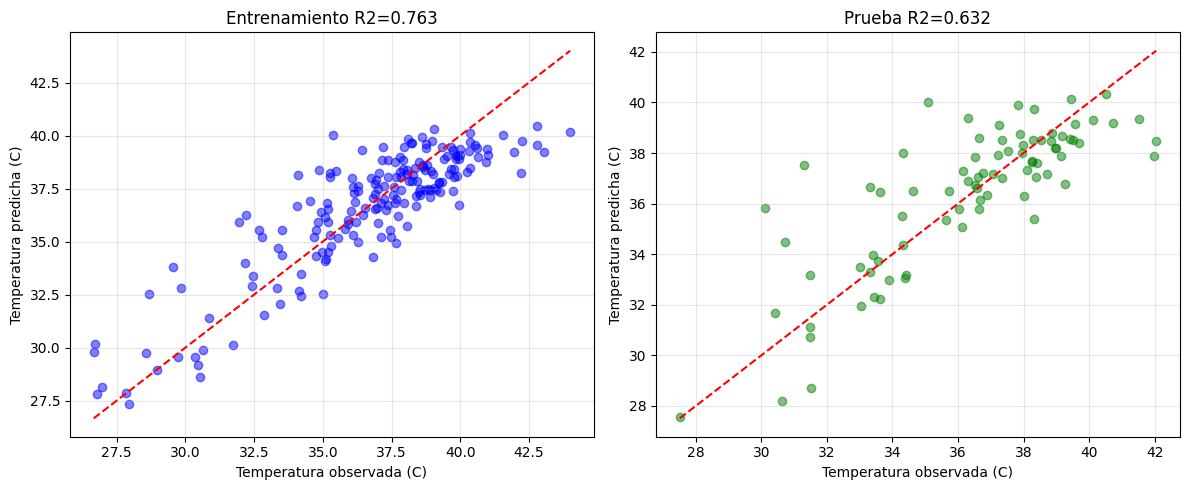

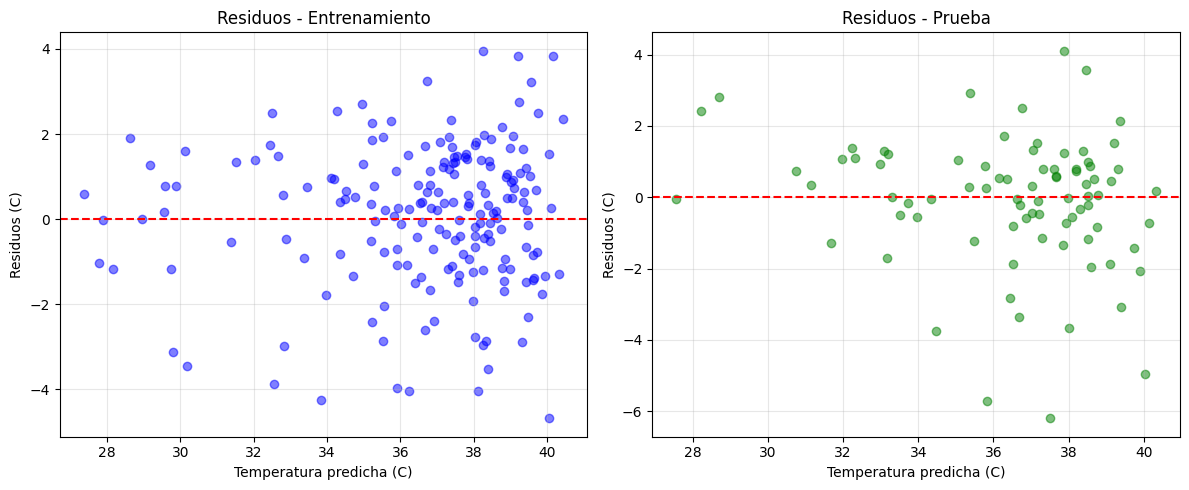

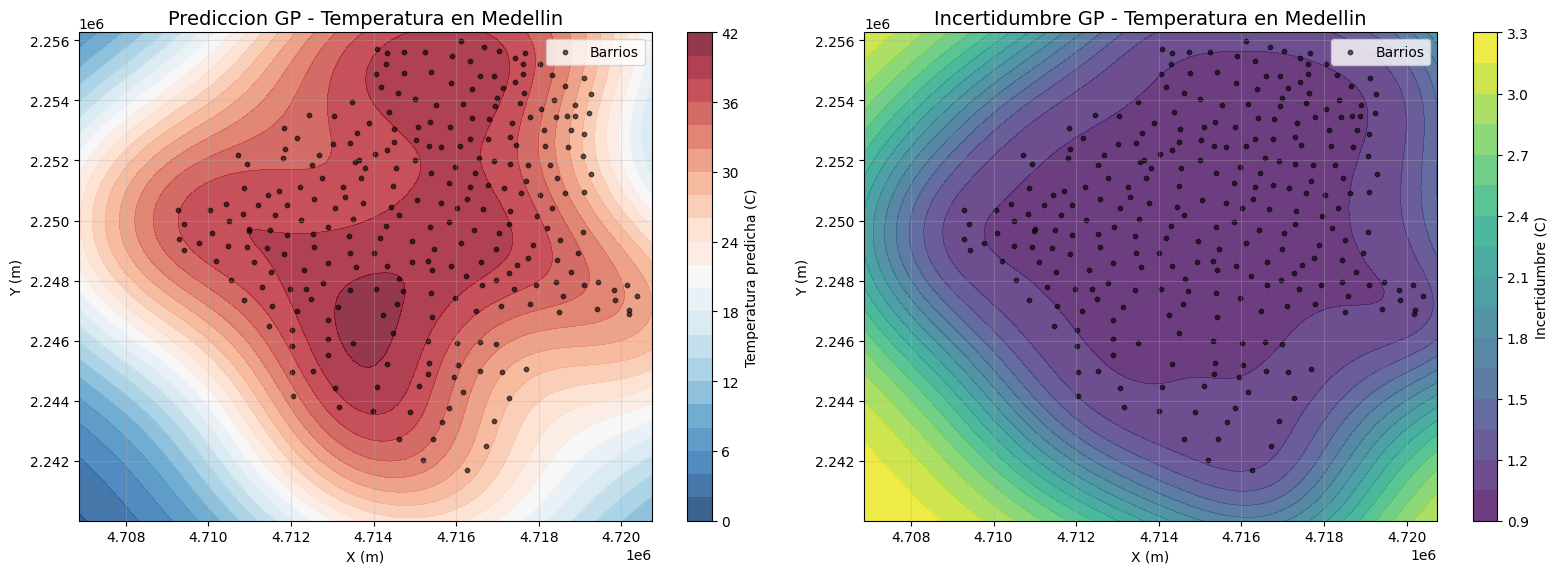


Resultados guardados en: Resultados_GP_Regresion.gpkg

RESUMEN FINAL DEL PROCESO GAUSSIANO

Kernel optimizado: 3.16**2 * RBF(length_scale=1.13) + WhiteKernel(noise_level=1)

R2 en entrenamiento: 0.7626
R2 en prueba: 0.6317
RMSE en prueba: 1.8369 C
MAE en prueba: 1.3101 C


In [ ]:
# ============================================
# 0. INSTALAR DEPENDENCIAS
# ============================================
!pip install scikit-learn -q

# ============================================
# 1. IMPORTAR LIBRERIAS
# ============================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. VERIFICAR QUE LOS ARCHIVOS ESTAN SUBIDOS
# ============================================
# Lista de archivos necesarios
archivos_necesarios = ["Zonas_Medellin.gpkg", "Temperatura_por_zona.csv"]

# Verificar que los archivos existen en la carpeta actual de Colab
for archivo in archivos_necesarios:
    if not os.path.exists(archivo):
        print("ERROR: No se encuentra el archivo:", archivo)
        print("")
        print("SOLUCION:")
        print("1. Haz clic en el icono de carpeta en el panel izquierdo de Colab.")
        print("2. Haz clic en el boton 'Subir archivo' (flecha hacia arriba).")
        print("3. Selecciona el archivo", archivo, "desde tu computadora.")
        print("4. Espera a que se complete la subida y vuelve a ejecutar esta celda.")
        raise FileNotFoundError("Archivo no encontrado: " + archivo)

print("Todos los archivos encontrados correctamente.")

# ============================================
# 3. CARGAR DATOS (USANDO SOLO NOMBRES DE ARCHIVO)
# ============================================
zonas = gpd.read_file("Zonas_Medellin.gpkg")
zonas_urbano = zonas[zonas['Tipo'] == 'Urbano'].copy()

df_temp = pd.read_csv("Temperatura_por_zona.csv")
temp_promedio = df_temp.groupby('ID').agg({'Temp_media': 'mean'}).reset_index()

zonas_urbano = zonas_urbano.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_urbano = zonas_urbano.dropna(subset=['Temp_media'])

print("Barrios urbanos con temperatura:", len(zonas_urbano))

# ============================================
# 4. DEFINIR VARIABLES
# ============================================
zonas_urbano['centroid'] = zonas_urbano.geometry.centroid
zonas_urbano['x'] = zonas_urbano['centroid'].x
zonas_urbano['y'] = zonas_urbano['centroid'].y

var_predictoras = ['x', 'y']
y = zonas_urbano['Temp_media'].values
X = zonas_urbano[var_predictoras].values

print("Variables predictoras:", var_predictoras)
print("Shape de X:", X.shape)

# ============================================
# 5. DIVIDIR DATOS
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
X_all_sc = scaler.transform(X)

print("Entrenamiento:", len(y_train), "puntos")
print("Prueba:", len(y_test), "puntos")

# ============================================
# 6. MODELO GP
# ============================================
kernel = ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0)) * \
         RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0)) + \
         WhiteKernel(noise_level=0.1, noise_level_bounds=(0.01, 1.0))

modelo_gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=0.0,
    random_state=42
)

print("Ajustando modelo GP...")
modelo_gp.fit(X_train_sc, y_train)
print("Kernel optimizado:", modelo_gp.kernel_)

# ============================================
# 7. PREDICCIONES
# ============================================
y_pred_train, y_std_train = modelo_gp.predict(X_train_sc, return_std=True)
y_pred_test, y_std_test = modelo_gp.predict(X_test_sc, return_std=True)
y_pred_all, y_std_all = modelo_gp.predict(X_all_sc, return_std=True)

# ============================================
# 8. METRICAS
# ============================================
def calcular_metricas(y_real, y_pred):
    return {
        'R2': r2_score(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'MAE': mean_absolute_error(y_real, y_pred)
    }

met_train = calcular_metricas(y_train, y_pred_train)
met_test = calcular_metricas(y_test, y_pred_test)

print("")
print("METRICAS DEL MODELO GP")
print("")
print("Entrenamiento:")
for k, v in met_train.items():
    print(" ", k, ":", round(v, 4))

print("")
print("Prueba:")
for k, v in met_test.items():
    print(" ", k, ":", round(v, 4))

# ============================================
# 9. GRAFICO PREDICCION VS OBSERVADO
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, y_pred_train, alpha=0.5, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel('Temperatura observada (C)')
axes[0].set_ylabel('Temperatura predicha (C)')
axes[0].set_title('Entrenamiento R2=' + str(round(met_train['R2'], 3)))
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Temperatura observada (C)')
axes[1].set_ylabel('Temperatura predicha (C)')
axes[1].set_title('Prueba R2=' + str(round(met_test['R2'], 3)))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("GP_Prediccion_vs_Observado.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 10. GRAFICO DE RESIDUOS
# ============================================
residuos_train = y_train - y_pred_train
residuos_test = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_train, residuos_train, alpha=0.5, color='blue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Temperatura predicha (C)')
axes[0].set_ylabel('Residuos (C)')
axes[0].set_title('Residuos - Entrenamiento')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_test, residuos_test, alpha=0.5, color='green')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Temperatura predicha (C)')
axes[1].set_ylabel('Residuos (C)')
axes[1].set_title('Residuos - Prueba')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("GP_Residuos.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 11. MAPA DE TEMPERATURA PREDICHA
# ============================================
xmin, ymin, xmax, ymax = zonas_urbano.total_bounds
resolucion = 80
x_grid = np.linspace(xmin, xmax, resolucion)
y_grid = np.linspace(ymin, ymax, resolucion)
X_pred = np.column_stack((np.meshgrid(x_grid, y_grid)[0].ravel(), np.meshgrid(x_grid, y_grid)[1].ravel()))
X_pred_sc = scaler.transform(X_pred)

y_pred_grid, y_std_grid = modelo_gp.predict(X_pred_sc, return_std=True)
y_pred_grid = y_pred_grid.reshape(len(y_grid), len(x_grid))
y_std_grid = y_std_grid.reshape(len(y_grid), len(x_grid))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
im = ax.contourf(x_grid, y_grid, y_pred_grid, levels=20, cmap='RdBu_r', alpha=0.8)
ax.scatter(zonas_urbano['x'], zonas_urbano['y'], c='black', s=10, alpha=0.6, label='Barrios')
plt.colorbar(im, ax=ax, label='Temperatura predicha (C)')
ax.set_title('Prediccion GP - Temperatura en Medellin', fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
im = ax.contourf(x_grid, y_grid, y_std_grid, levels=20, cmap='viridis', alpha=0.8)
ax.scatter(zonas_urbano['x'], zonas_urbano['y'], c='black', s=10, alpha=0.6, label='Barrios')
plt.colorbar(im, ax=ax, label='Incertidumbre (C)')
ax.set_title('Incertidumbre GP - Temperatura en Medellin', fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("GP_Mapa_Temperatura.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 12. GUARDAR RESULTADOS (CORREGIDO)
# ============================================
# Agregar las predicciones al GeoDataFrame original
zonas_urbano['Temp_pred_GP'] = y_pred_all
zonas_urbano['Temp_std_GP'] = y_std_all
zonas_urbano['Residuo_GP'] = y - y_pred_all

# Eliminar columnas de geometría adicionales que causan conflicto
# Conservar solo la geometría original ('geometry')
columnas_para_guardar = ['Temp_pred_GP', 'Temp_std_GP', 'Residuo_GP', 'geometry']

# Si existe 'centroid', la eliminamos
if 'centroid' in zonas_urbano.columns:
    zonas_urbano = zonas_urbano.drop(columns=['centroid'])

# Si existe 'x', la eliminamos (no la necesitas en el archivo final)
if 'x' in zonas_urbano.columns:
    zonas_urbano = zonas_urbano.drop(columns=['x', 'y'])

# Crear un GeoDataFrame con solo las columnas necesarias
gdf_final = zonas_urbano[columnas_para_guardar].copy()

# Guardar el archivo
ruta_salida = "Resultados_GP_Regresion.gpkg"
gdf_final.to_file(ruta_salida, layer="Resultados_GP", driver="GPKG")
print("")
print("Resultados guardados en:", ruta_salida)

# ============================================
# 13. RESUMEN FINAL
# ============================================
print("")
print("RESUMEN FINAL DEL PROCESO GAUSSIANO")
print("")
print("Kernel optimizado:", modelo_gp.kernel_)
print("")
print("R2 en entrenamiento:", round(met_train['R2'], 4))
print("R2 en prueba:", round(met_test['R2'], 4))
print("RMSE en prueba:", round(met_test['RMSE'], 4), "C")
print("MAE en prueba:", round(met_test['MAE'], 4), "C")

Todos los archivos encontrados correctamente.
Barrios urbanos con temperatura: 271
Densidad de árboles calculada.
Media de densidad: 1803.78 arboles/km2
Variables predictoras: ['x', 'y', 'densidad_arboles']
Shape de X: (271, 3)
Entrenamiento: 189 puntos
Prueba: 82 puntos
Ajustando modelo GP...
Kernel optimizado: 3.16**2 * RBF(length_scale=[1.27, 1.02, 10]) + WhiteKernel(noise_level=1)

METRICAS DEL MODELO GP

Entrenamiento:
  R2 : 0.7902
  RMSE : 1.557
  MAE : 1.2342

Prueba:
  R2 : 0.6537
  RMSE : 1.7811
  MAE : 1.2993


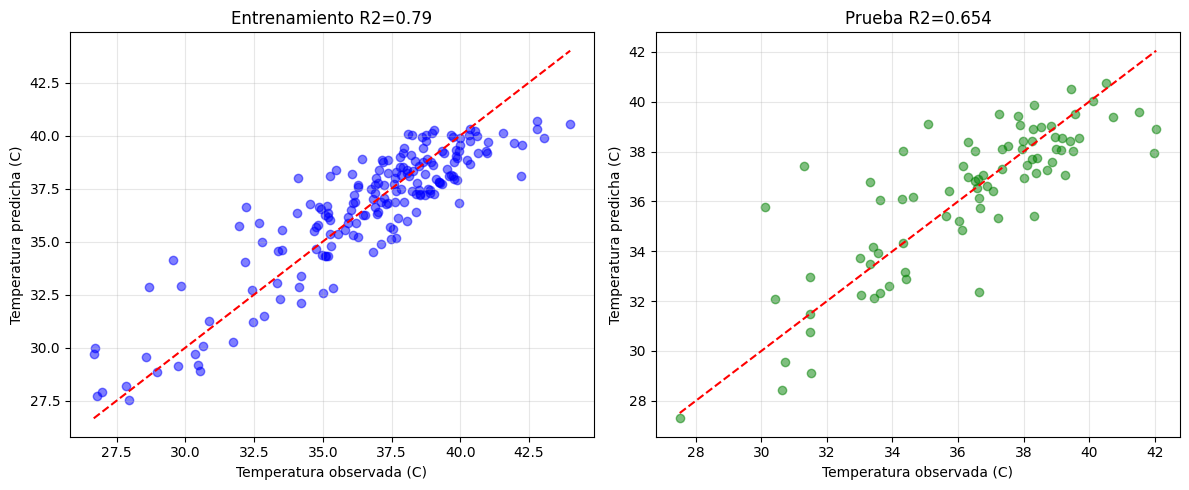

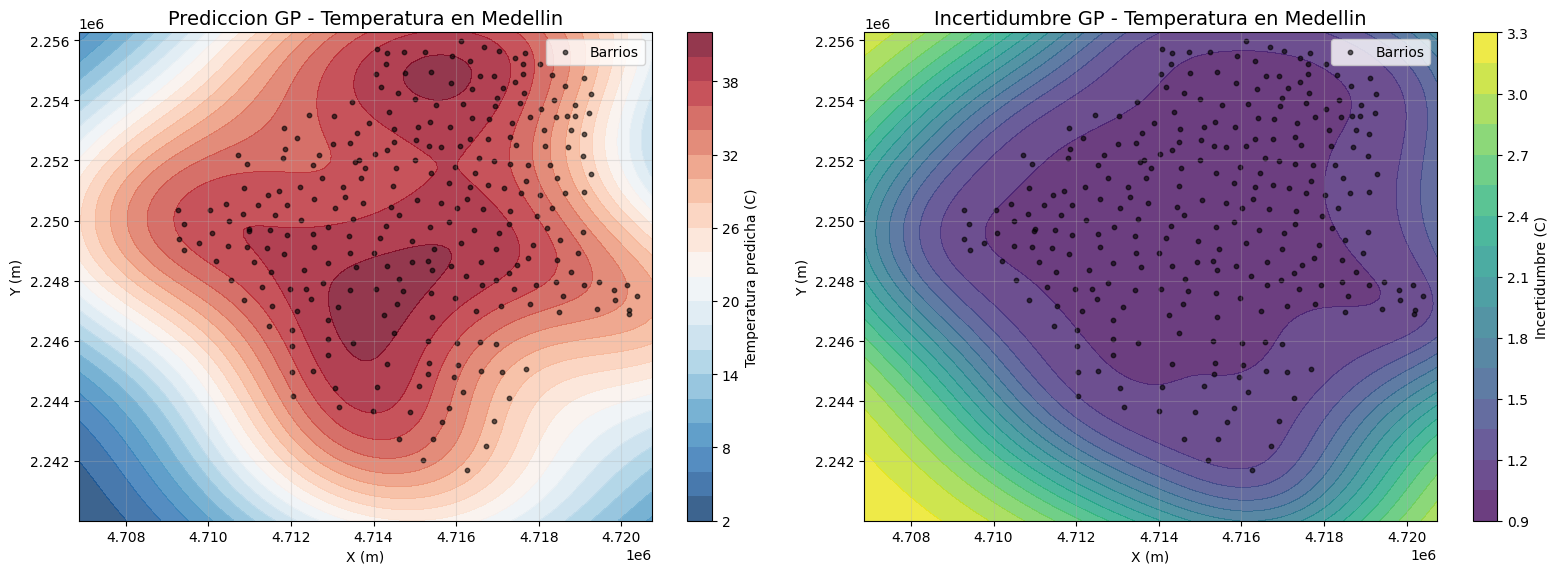


Resultados guardados en: Resultados_GP_Regresion.gpkg

RESUMEN FINAL DEL PROCESO GAUSSIANO

Variables predictoras: ['x', 'y', 'densidad_arboles']
Kernel optimizado: 3.16**2 * RBF(length_scale=[1.27, 1.02, 10]) + WhiteKernel(noise_level=1)

R2 en entrenamiento: 0.7902
R2 en prueba: 0.6537
RMSE en prueba: 1.7811 C
MAE en prueba: 1.2993 C


In [ ]:
# ============================================
# 0. INSTALAR DEPENDENCIAS
# ============================================
!pip install scikit-learn -q

# ============================================
# 1. IMPORTAR LIBRERIAS
# ============================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. VERIFICAR ARCHIVOS
# ============================================
archivos_necesarios = ["Zonas_Medellin.gpkg", "Temperatura_por_zona.csv", "Arboles_Activos_Medellin_TODOS.gpkg"]

for archivo in archivos_necesarios:
    if not os.path.exists(archivo):
        print("ERROR: No se encuentra el archivo:", archivo)
        print("Sube el archivo al panel de archivos de Colab.")
        raise FileNotFoundError("Archivo no encontrado: " + archivo)

print("Todos los archivos encontrados correctamente.")

# ============================================
# 3. CARGAR DATOS
# ============================================
zonas = gpd.read_file("Zonas_Medellin.gpkg")
zonas_urbano = zonas[zonas['Tipo'] == 'Urbano'].copy()

df_temp = pd.read_csv("Temperatura_por_zona.csv")
temp_promedio = df_temp.groupby('ID').agg({'Temp_media': 'mean'}).reset_index()

zonas_urbano = zonas_urbano.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_urbano = zonas_urbano.dropna(subset=['Temp_media'])

print("Barrios urbanos con temperatura:", len(zonas_urbano))

# ============================================
# 4. CALCULAR DENSIDAD DE ARBOLES
# ============================================
arboles = gpd.read_file("Arboles_Activos_Medellin_TODOS.gpkg")

# Contar árboles por barrio
arboles_en_zonas = gpd.sjoin(arboles, zonas_urbano, how='inner', predicate='within')
conteo_arboles = arboles_en_zonas.groupby('ID').size().reset_index(name='num_arboles')
zonas_urbano = zonas_urbano.merge(conteo_arboles, on='ID', how='left')
zonas_urbano['num_arboles'] = zonas_urbano['num_arboles'].fillna(0).astype(int)

# Calcular área y densidad
zonas_urbano['area_km2'] = zonas_urbano.geometry.area / 1_000_000
zonas_urbano['densidad_arboles'] = zonas_urbano['num_arboles'] / zonas_urbano['area_km2']

print("Densidad de árboles calculada.")
print("Media de densidad:", round(zonas_urbano['densidad_arboles'].mean(), 2), "arboles/km2")

# ============================================
# 5. DEFINIR VARIABLES (COORDENADAS + DENSIDAD)
# ============================================
zonas_urbano['centroid'] = zonas_urbano.geometry.centroid
zonas_urbano['x'] = zonas_urbano['centroid'].x
zonas_urbano['y'] = zonas_urbano['centroid'].y

var_predictoras = ['x', 'y', 'densidad_arboles']

y = zonas_urbano['Temp_media'].values
X = zonas_urbano[var_predictoras].values

print("Variables predictoras:", var_predictoras)
print("Shape de X:", X.shape)

# ============================================
# 6. DIVIDIR DATOS
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
X_all_sc = scaler.transform(X)

print("Entrenamiento:", len(y_train), "puntos")
print("Prueba:", len(y_test), "puntos")

# ============================================
# 7. MODELO GP
# ============================================
n_features = X.shape[1]

kernel = ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0)) * \
         RBF(length_scale=np.ones(n_features), length_scale_bounds=(0.1, 10.0)) + \
         WhiteKernel(noise_level=0.1, noise_level_bounds=(0.01, 1.0))

modelo_gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=0.0,
    random_state=42
)

print("Ajustando modelo GP...")
modelo_gp.fit(X_train_sc, y_train)
print("Kernel optimizado:", modelo_gp.kernel_)

# ============================================
# 8. PREDICCIONES
# ============================================
y_pred_train, y_std_train = modelo_gp.predict(X_train_sc, return_std=True)
y_pred_test, y_std_test = modelo_gp.predict(X_test_sc, return_std=True)
y_pred_all, y_std_all = modelo_gp.predict(X_all_sc, return_std=True)

# ============================================
# 9. METRICAS
# ============================================
def calcular_metricas(y_real, y_pred):
    return {
        'R2': r2_score(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'MAE': mean_absolute_error(y_real, y_pred)
    }

met_train = calcular_metricas(y_train, y_pred_train)
met_test = calcular_metricas(y_test, y_pred_test)

print("")
print("METRICAS DEL MODELO GP")
print("")
print("Entrenamiento:")
for k, v in met_train.items():
    print(" ", k, ":", round(v, 4))

print("")
print("Prueba:")
for k, v in met_test.items():
    print(" ", k, ":", round(v, 4))

# ============================================
# 10. GRAFICO PREDICCION VS OBSERVADO
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, y_pred_train, alpha=0.5, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel('Temperatura observada (C)')
axes[0].set_ylabel('Temperatura predicha (C)')
axes[0].set_title('Entrenamiento R2=' + str(round(met_train['R2'], 3)))
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Temperatura observada (C)')
axes[1].set_ylabel('Temperatura predicha (C)')
axes[1].set_title('Prueba R2=' + str(round(met_test['R2'], 3)))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("GP_Prediccion_vs_Observado.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 11. MAPA DE TEMPERATURA PREDICHA
# ============================================
xmin, ymin, xmax, ymax = zonas_urbano.total_bounds
resolucion = 80
x_grid = np.linspace(xmin, xmax, resolucion)
y_grid = np.linspace(ymin, ymax, resolucion)

X_pred = np.column_stack((np.meshgrid(x_grid, y_grid)[0].ravel(), np.meshgrid(x_grid, y_grid)[1].ravel()))

# Para la densidad en la cuadrícula, usamos el valor medio
densidad_media = zonas_urbano['densidad_arboles'].mean()
densidad_grid = np.ones(X_pred.shape[0]) * densidad_media
X_pred = np.column_stack([X_pred, densidad_grid])

X_pred_sc = scaler.transform(X_pred)

y_pred_grid, y_std_grid = modelo_gp.predict(X_pred_sc, return_std=True)
y_pred_grid = y_pred_grid.reshape(len(y_grid), len(x_grid))
y_std_grid = y_std_grid.reshape(len(y_grid), len(x_grid))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
im = ax.contourf(x_grid, y_grid, y_pred_grid, levels=20, cmap='RdBu_r', alpha=0.8)
ax.scatter(zonas_urbano['x'], zonas_urbano['y'], c='black', s=10, alpha=0.6, label='Barrios')
plt.colorbar(im, ax=ax, label='Temperatura predicha (C)')
ax.set_title('Prediccion GP - Temperatura en Medellin', fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
im = ax.contourf(x_grid, y_grid, y_std_grid, levels=20, cmap='viridis', alpha=0.8)
ax.scatter(zonas_urbano['x'], zonas_urbano['y'], c='black', s=10, alpha=0.6, label='Barrios')
plt.colorbar(im, ax=ax, label='Incertidumbre (C)')
ax.set_title('Incertidumbre GP - Temperatura en Medellin', fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("GP_Mapa_Temperatura.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 12. GUARDAR RESULTADOS
# ============================================
zonas_urbano['Temp_pred_GP'] = y_pred_all
zonas_urbano['Temp_std_GP'] = y_std_all
zonas_urbano['Residuo_GP'] = y - y_pred_all

if 'centroid' in zonas_urbano.columns:
    zonas_urbano = zonas_urbano.drop(columns=['centroid'])
if 'x' in zonas_urbano.columns:
    zonas_urbano = zonas_urbano.drop(columns=['x', 'y'])

columnas_para_guardar = ['Temp_pred_GP', 'Temp_std_GP', 'Residuo_GP', 'geometry']
gdf_final = zonas_urbano[columnas_para_guardar].copy()

ruta_salida = "Resultados_GP_Regresion.gpkg"
gdf_final.to_file(ruta_salida, layer="Resultados_GP", driver="GPKG")
print("")
print("Resultados guardados en:", ruta_salida)

# ============================================
# 13. RESUMEN FINAL
# ============================================
print("")
print("RESUMEN FINAL DEL PROCESO GAUSSIANO")
print("")
print("Variables predictoras:", var_predictoras)
print("Kernel optimizado:", modelo_gp.kernel_)
print("")
print("R2 en entrenamiento:", round(met_train['R2'], 4))
print("R2 en prueba:", round(met_test['R2'], 4))
print("RMSE en prueba:", round(met_test['RMSE'], 4), "C")
print("MAE en prueba:", round(met_test['MAE'], 4), "C")

Todos los archivos encontrados correctamente.
Barrios urbanos con temperatura: 271
Variables predictoras: ['x', 'y', 'densidad_arboles']
Shape de X: (271, 3)
Entrenamiento: 189 puntos
Prueba: 82 puntos

MODELO CON KERNEL FIJO
Kernel inicial:
1**2 * RBF(length_scale=[1, 1, 1]) + WhiteKernel(noise_level=0.1)

Hiperparámetros fijos:
{'k1': 1**2 * RBF(length_scale=[1, 1, 1]), 'k2': WhiteKernel(noise_level=0.1), 'k1__k1': 1**2, 'k1__k2': RBF(length_scale=[1, 1, 1]), 'k1__k1__constant_value': 1.0, 'k1__k1__constant_value_bounds': 'fixed', 'k1__k2__length_scale': array([1., 1., 1.]), 'k1__k2__length_scale_bounds': 'fixed', 'k2__noise_level': 0.1, 'k2__noise_level_bounds': 'fixed'}

R2 entrenamiento: 0.8205
R2 prueba: -0.1143
RMSE prueba: 3.1949 C
MAE prueba: 1.8069 C

MODELO CON KERNEL OPTIMIZADO
Kernel inicial:
1**2 * RBF(length_scale=[1, 1, 1]) + WhiteKernel(noise_level=0.1)

Kernel optimizado:
3.16**2 * RBF(length_scale=[1.27, 1.02, 10]) + WhiteKernel(noise_level=1)

Theta optimizado (esca

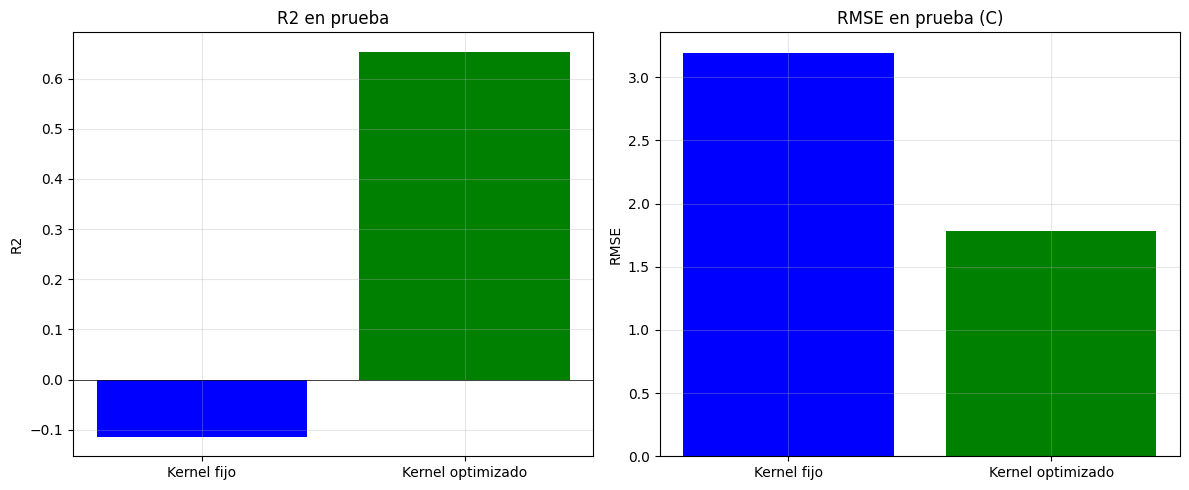

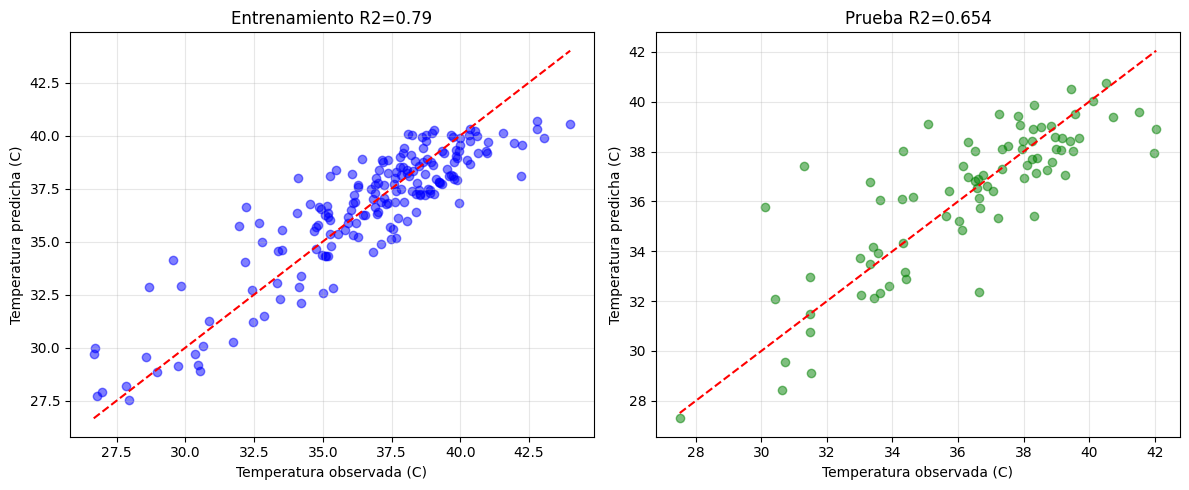

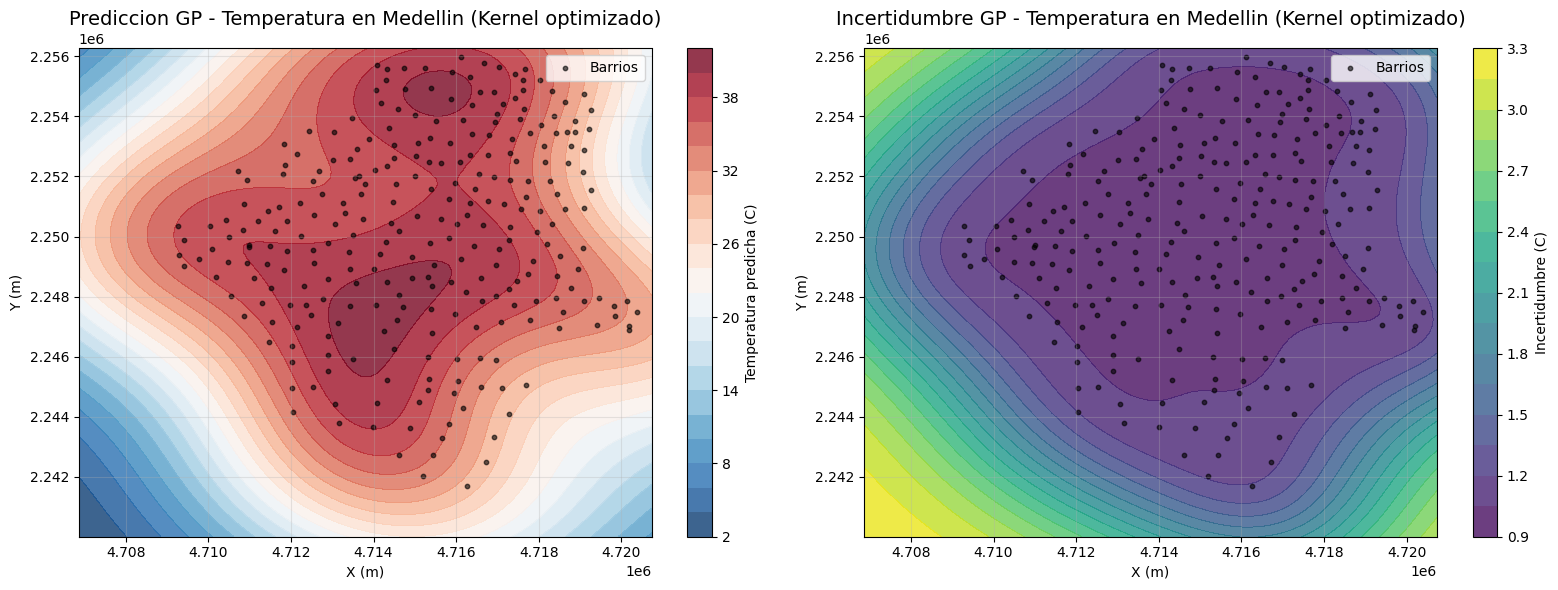


Resultados guardados en: Resultados_GP_Regresion_Optimizado.gpkg

RESUMEN FINAL

Variables predictoras: ['x', 'y', 'densidad_arboles']

Kernel optimizado:
3.16**2 * RBF(length_scale=[1.27, 1.02, 10]) + WhiteKernel(noise_level=1)

Theta (hiperparámetros en escala log):
[2.30258509 0.23605934 0.02373093 2.30258509 0.        ]

Log-verosimilitud marginal: -731.5898999208067

R2 en prueba: 0.6537
RMSE en prueba: 1.7811 C
MAE en prueba: 1.2993 C


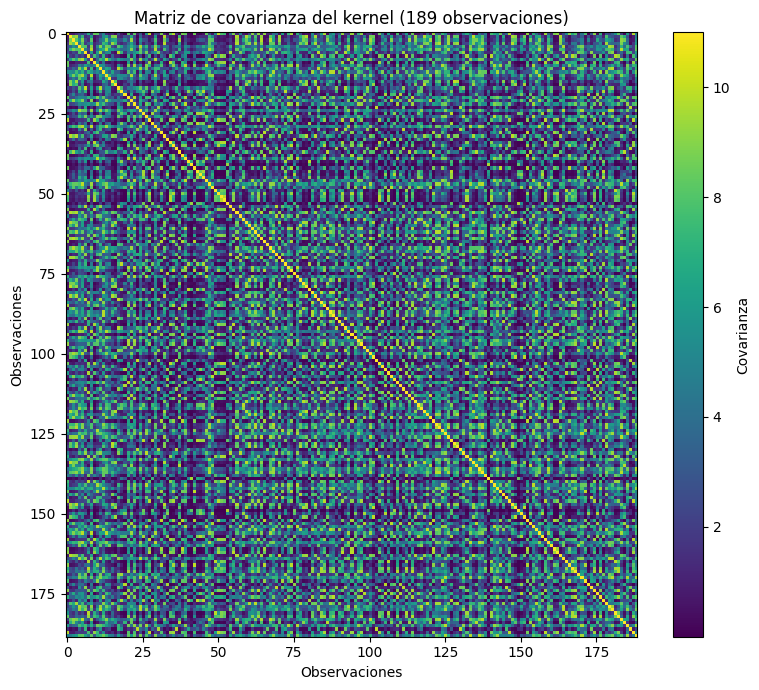

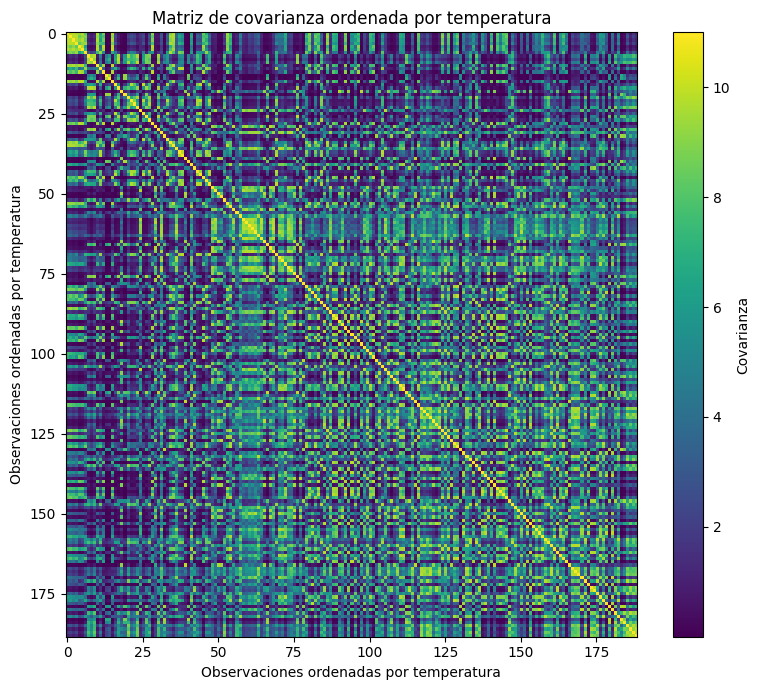

Matrices de covarianza guardadas.


In [ ]:
# ============================================
# 0. INSTALAR DEPENDENCIAS
# ============================================
!pip install scikit-learn -q

# ============================================
# 1. IMPORTAR LIBRERIAS
# ============================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. VERIFICAR ARCHIVOS
# ============================================
archivos_necesarios = ["Zonas_Medellin.gpkg", "Temperatura_por_zona.csv", "Arboles_Activos_Medellin_TODOS.gpkg"]

for archivo in archivos_necesarios:
    if not os.path.exists(archivo):
        print("ERROR: No se encuentra el archivo:", archivo)
        print("Sube el archivo al panel de archivos de Colab.")
        raise FileNotFoundError("Archivo no encontrado: " + archivo)

print("Todos los archivos encontrados correctamente.")

# ============================================
# 3. CARGAR DATOS Y CALCULAR DENSIDAD
# ============================================
zonas = gpd.read_file("Zonas_Medellin.gpkg")
zonas_urbano = zonas[zonas['Tipo'] == 'Urbano'].copy()

df_temp = pd.read_csv("Temperatura_por_zona.csv")
temp_promedio = df_temp.groupby('ID').agg({'Temp_media': 'mean'}).reset_index()

zonas_urbano = zonas_urbano.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_urbano = zonas_urbano.dropna(subset=['Temp_media'])

print("Barrios urbanos con temperatura:", len(zonas_urbano))

# Calcular densidad de árboles
arboles = gpd.read_file("Arboles_Activos_Medellin_TODOS.gpkg")
arboles_en_zonas = gpd.sjoin(arboles, zonas_urbano, how='inner', predicate='within')
conteo_arboles = arboles_en_zonas.groupby('ID').size().reset_index(name='num_arboles')
zonas_urbano = zonas_urbano.merge(conteo_arboles, on='ID', how='left')
zonas_urbano['num_arboles'] = zonas_urbano['num_arboles'].fillna(0).astype(int)
zonas_urbano['area_km2'] = zonas_urbano.geometry.area / 1_000_000
zonas_urbano['densidad_arboles'] = zonas_urbano['num_arboles'] / zonas_urbano['area_km2']

# Coordenadas
zonas_urbano['centroid'] = zonas_urbano.geometry.centroid
zonas_urbano['x'] = zonas_urbano['centroid'].x
zonas_urbano['y'] = zonas_urbano['centroid'].y

# ============================================
# 4. DEFINIR VARIABLES
# ============================================
# Variables predictoras
var_predictoras = ['x', 'y', 'densidad_arboles']
# var_predictoras = ['x', 'y']  # Solo espacial
# var_predictoras = ['densidad_arboles']  # Solo densidad

# Variable respuesta
y = zonas_urbano['Temp_media'].values
X = zonas_urbano[var_predictoras].values

print("Variables predictoras:", var_predictoras)
print("Shape de X:", X.shape)

# ============================================
# 5. DIVIDIR DATOS
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Entrenamiento:", len(y_train), "puntos")
print("Prueba:", len(y_test), "puntos")

# ============================================
# 6. DEFINIR FUNCION DE METRICAS
# ============================================
def calcular_metricas_regresion(y_real, y_pred):
    return {
        'R2': r2_score(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'MAE': mean_absolute_error(y_real, y_pred)
    }

# ============================================
# 7. MODELO CON KERNEL FIJO (SIN OPTIMIZAR)
# ============================================
n_var = len(var_predictoras)

kernel_fijo = ConstantKernel(
    constant_value=1.0,
    constant_value_bounds="fixed"
) * RBF(
    length_scale=np.ones(n_var),
    length_scale_bounds="fixed"
) + WhiteKernel(
    noise_level=0.1,
    noise_level_bounds="fixed"
)

modelo_fijo = GaussianProcessRegressor(
    kernel=kernel_fijo,
    optimizer=None,  # No optimiza
    alpha=0.0,
    random_state=42
)

print("\n" + "="*60)
print("MODELO CON KERNEL FIJO")
print("="*60)
print("Kernel inicial:")
print(kernel_fijo)
print("\nHiperparámetros fijos:")
print(kernel_fijo.get_params())

modelo_fijo.fit(X_train_sc, y_train)

y_pred_train_fijo, _ = modelo_fijo.predict(X_train_sc, return_std=True)
y_pred_test_fijo, _ = modelo_fijo.predict(X_test_sc, return_std=True)

met_train_fijo = calcular_metricas_regresion(y_train, y_pred_train_fijo)
met_test_fijo = calcular_metricas_regresion(y_test, y_pred_test_fijo)

print("\nR2 entrenamiento:", round(met_train_fijo['R2'], 4))
print("R2 prueba:", round(met_test_fijo['R2'], 4))
print("RMSE prueba:", round(met_test_fijo['RMSE'], 4), "C")
print("MAE prueba:", round(met_test_fijo['MAE'], 4), "C")

# ============================================
# 8. MODELO CON KERNEL OPTIMIZADO
# ============================================
kernel_optimizable = ConstantKernel(
    constant_value=1.0,
    constant_value_bounds=(0.1, 10.0)
) * RBF(
    length_scale=np.ones(n_var),
    length_scale_bounds=(0.1, 10.0)
) + WhiteKernel(
    noise_level=0.1,
    noise_level_bounds=(0.01, 1.0)
)

modelo_optimizado = GaussianProcessRegressor(
    kernel=kernel_optimizable,
    n_restarts_optimizer=10,
    alpha=0.0,
    random_state=42
)

print("\n" + "="*60)
print("MODELO CON KERNEL OPTIMIZADO")
print("="*60)
print("Kernel inicial:")
print(kernel_optimizable)

modelo_optimizado.fit(X_train_sc, y_train)

print("\nKernel optimizado:")
print(modelo_optimizado.kernel_)
print("\nTheta optimizado (escala log):")
print(modelo_optimizado.kernel_.theta)
print("\nLog-verosimilitud marginal:")
print(modelo_optimizado.log_marginal_likelihood_value_)

y_pred_train_opt, _ = modelo_optimizado.predict(X_train_sc, return_std=True)
y_pred_test_opt, _ = modelo_optimizado.predict(X_test_sc, return_std=True)

met_train_opt = calcular_metricas_regresion(y_train, y_pred_train_opt)
met_test_opt = calcular_metricas_regresion(y_test, y_pred_test_opt)

print("\nR2 entrenamiento:", round(met_train_opt['R2'], 4))
print("R2 prueba:", round(met_test_opt['R2'], 4))
print("RMSE prueba:", round(met_test_opt['RMSE'], 4), "C")
print("MAE prueba:", round(met_test_opt['MAE'], 4), "C")

# ============================================
# 9. TABLA COMPARATIVA
# ============================================
comparacion = pd.DataFrame({
    'Modelo': ['Kernel fijo', 'Kernel optimizado'],
    'R2_train': [met_train_fijo['R2'], met_train_opt['R2']],
    'R2_test': [met_test_fijo['R2'], met_test_opt['R2']],
    'RMSE_test': [met_test_fijo['RMSE'], met_test_opt['RMSE']],
    'MAE_test': [met_test_fijo['MAE'], met_test_opt['MAE']]
})

print("\n" + "="*60)
print("TABLA COMPARATIVA")
print("="*60)
print(comparacion.round(4).to_string(index=False))

# ============================================
# 10. GRAFICO COMPARATIVO
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R2
axes[0].bar(comparacion['Modelo'], comparacion['R2_test'], color=['blue', 'green'])
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('R2 en prueba')
axes[0].set_ylabel('R2')
axes[0].grid(True, alpha=0.3)

# RMSE
axes[1].bar(comparacion['Modelo'], comparacion['RMSE_test'], color=['blue', 'green'])
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('RMSE en prueba (C)')
axes[1].set_ylabel('RMSE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Comparacion_Kernels_GP.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 11. GRAFICO PREDICCION VS OBSERVADO (MEJOR MODELO)
# ============================================
modelo_mejor = modelo_optimizado
met_mejor = met_test_opt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Entrenamiento
axes[0].scatter(y_train, y_pred_train_opt, alpha=0.5, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel('Temperatura observada (C)')
axes[0].set_ylabel('Temperatura predicha (C)')
axes[0].set_title('Entrenamiento R2=' + str(round(met_train_opt['R2'], 3)))
axes[0].grid(True, alpha=0.3)

# Prueba
axes[1].scatter(y_test, y_pred_test_opt, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Temperatura observada (C)')
axes[1].set_ylabel('Temperatura predicha (C)')
axes[1].set_title('Prueba R2=' + str(round(met_test_opt['R2'], 3)))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("GP_Prediccion_vs_Observado_Optimizado.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 12. MAPA DE TEMPERATURA PREDICHA (MEJOR MODELO)
# ============================================
xmin, ymin, xmax, ymax = zonas_urbano.total_bounds
resolucion = 80
x_grid = np.linspace(xmin, xmax, resolucion)
y_grid = np.linspace(ymin, ymax, resolucion)

X_pred = np.column_stack((np.meshgrid(x_grid, y_grid)[0].ravel(), np.meshgrid(x_grid, y_grid)[1].ravel()))

# Para la densidad en la cuadrícula, usamos el valor medio
densidad_media = zonas_urbano['densidad_arboles'].mean()
densidad_grid = np.ones(X_pred.shape[0]) * densidad_media
X_pred = np.column_stack([X_pred, densidad_grid])

X_pred_sc = scaler.transform(X_pred)

y_pred_grid, y_std_grid = modelo_mejor.predict(X_pred_sc, return_std=True)
y_pred_grid = y_pred_grid.reshape(len(y_grid), len(x_grid))
y_std_grid = y_std_grid.reshape(len(y_grid), len(x_grid))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
im = ax.contourf(x_grid, y_grid, y_pred_grid, levels=20, cmap='RdBu_r', alpha=0.8)
ax.scatter(zonas_urbano['x'], zonas_urbano['y'], c='black', s=10, alpha=0.6, label='Barrios')
plt.colorbar(im, ax=ax, label='Temperatura predicha (C)')
ax.set_title('Prediccion GP - Temperatura en Medellin (Kernel optimizado)', fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
im = ax.contourf(x_grid, y_grid, y_std_grid, levels=20, cmap='viridis', alpha=0.8)
ax.scatter(zonas_urbano['x'], zonas_urbano['y'], c='black', s=10, alpha=0.6, label='Barrios')
plt.colorbar(im, ax=ax, label='Incertidumbre (C)')
ax.set_title('Incertidumbre GP - Temperatura en Medellin (Kernel optimizado)', fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("GP_Mapa_Temperatura_Optimizado.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 13. GUARDAR RESULTADOS
# ============================================
zonas_urbano['Temp_pred_GP'] = modelo_mejor.predict(X_all_sc)
zonas_urbano['Temp_std_GP'] = modelo_mejor.predict(X_all_sc, return_std=True)[1]
zonas_urbano['Residuo_GP'] = y - zonas_urbano['Temp_pred_GP']

if 'centroid' in zonas_urbano.columns:
    zonas_urbano = zonas_urbano.drop(columns=['centroid'])
if 'x' in zonas_urbano.columns:
    zonas_urbano = zonas_urbano.drop(columns=['x', 'y'])

columnas_para_guardar = ['Temp_pred_GP', 'Temp_std_GP', 'Residuo_GP', 'geometry']
gdf_final = zonas_urbano[columnas_para_guardar].copy()

ruta_salida = "Resultados_GP_Regresion_Optimizado.gpkg"
gdf_final.to_file(ruta_salida, layer="Resultados_GP", driver="GPKG")
print("\nResultados guardados en:", ruta_salida)

# ============================================
# 14. RESUMEN FINAL
# ============================================
print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)
print("\nVariables predictoras:", var_predictoras)
print("\nKernel optimizado:")
print(modelo_mejor.kernel_)
print("\nTheta (hiperparámetros en escala log):")
print(modelo_mejor.kernel_.theta)
print("\nLog-verosimilitud marginal:", modelo_mejor.log_marginal_likelihood_value_)
print("\nR2 en prueba:", round(met_mejor['R2'], 4))
print("RMSE en prueba:", round(met_mejor['RMSE'], 4), "C")
print("MAE en prueba:", round(met_mejor['MAE'], 4), "C")


Kernel: RBF


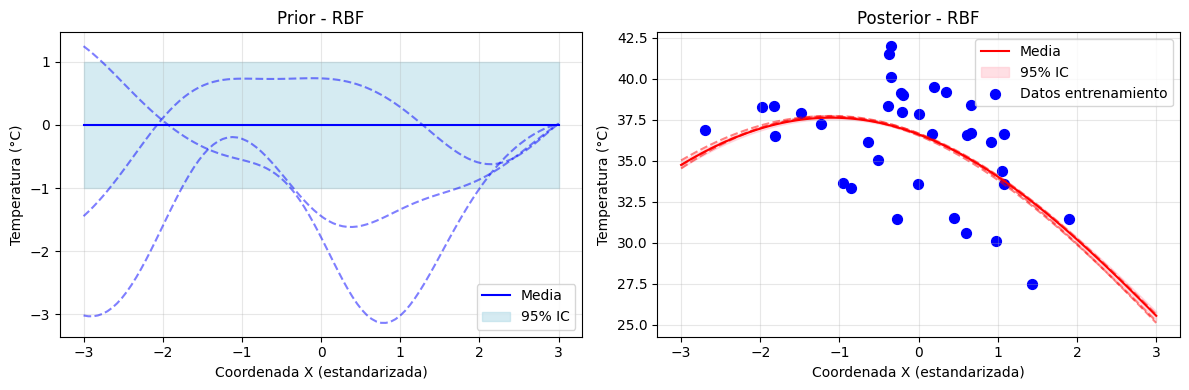

Kernel optimizado: RBF(length_scale=4.72)
Log-verosimilitud marginal: -2101.4583

Kernel: RationalQuadratic


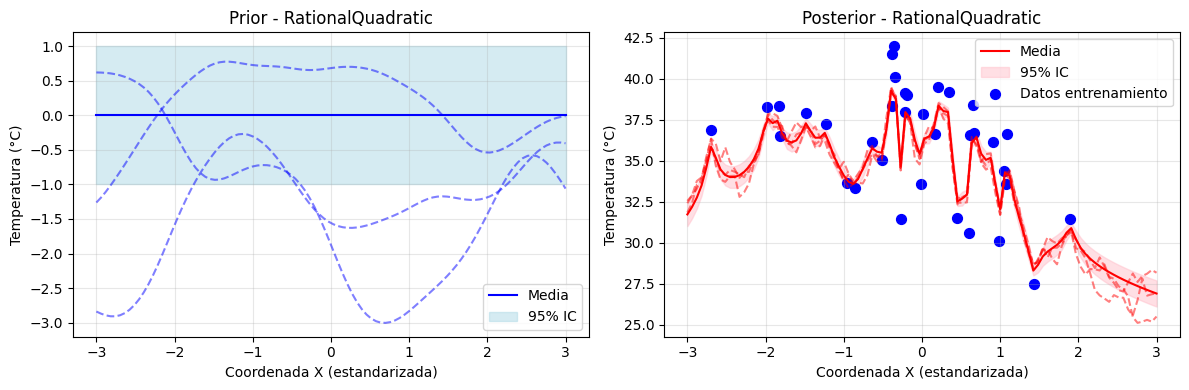

Kernel optimizado: RationalQuadratic(alpha=0.1, length_scale=0.1)
Log-verosimilitud marginal: -1721.7991

Kernel: Matern


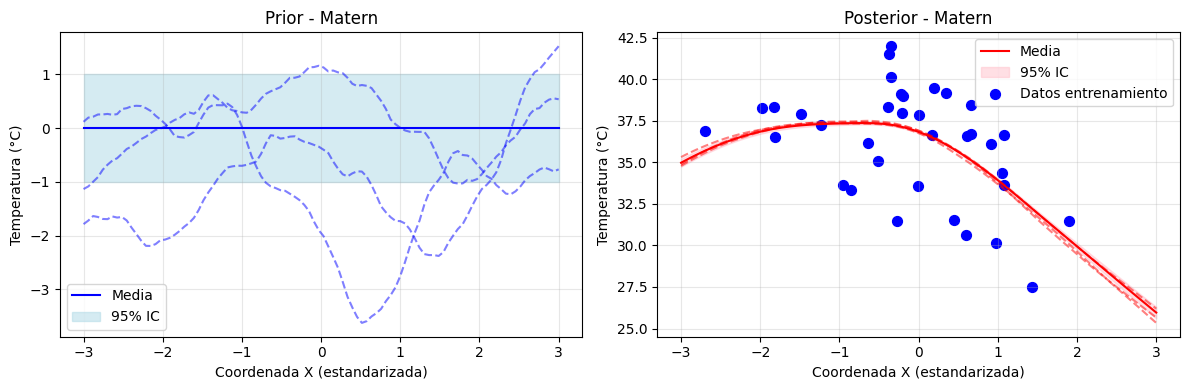

Kernel optimizado: Matern(length_scale=6.34, nu=1.5)
Log-verosimilitud marginal: -2084.8075

Kernel: RBF + WhiteKernel


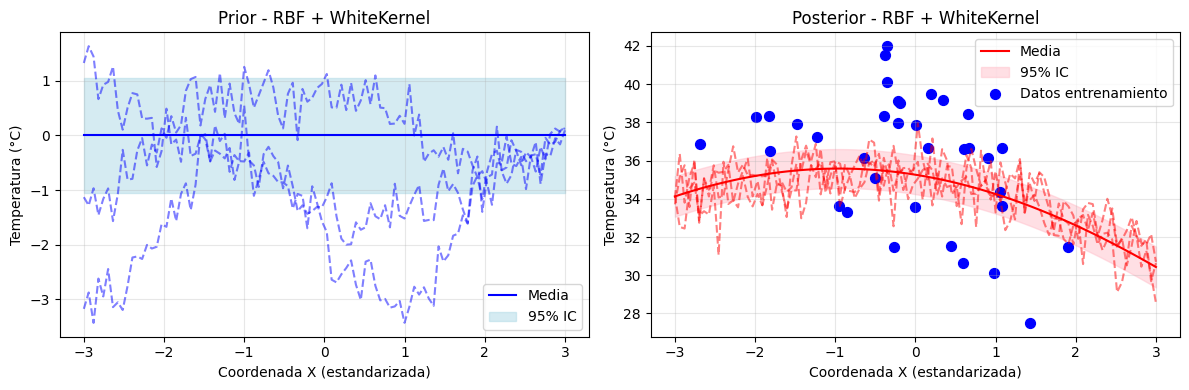

Kernel optimizado: RBF(length_scale=7.07) + WhiteKernel(noise_level=1)
Log-verosimilitud marginal: -835.4493


In [ ]:
# ============================================
# COMPARACIÓN DE KERNELS (CORREGIDO)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 1. Preparar datos (usar una muestra para visualización)
np.random.seed(42)
idx_muestra = np.random.choice(len(zonas_urbano), 50, replace=False)
zonas_muestra = zonas_urbano.iloc[idx_muestra].copy()

# Recalcular coordenadas si no existen
if 'x' not in zonas_muestra.columns:
    zonas_muestra['centroid'] = zonas_muestra.geometry.centroid
    zonas_muestra['x'] = zonas_muestra['centroid'].x
    zonas_muestra['y'] = zonas_muestra['centroid'].y

# Variables predictoras (coordenadas + densidad)
var_predictoras = ['x', 'y', 'densidad_arboles']
y = zonas_muestra['Temp_media'].values
X = zonas_muestra[var_predictoras].values

# Estandarizar
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y, test_size=0.30, random_state=42
)

# ============================================
# DEFINIR LOS KERNELS A COMPARAR
# ============================================
kernels_list = [
    ('RBF', kernels.RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0))),
    ('RationalQuadratic', kernels.RationalQuadratic(length_scale=1.0, alpha=1.0,
                                                    length_scale_bounds=(0.1, 10.0),
                                                    alpha_bounds=(0.1, 10.0))),
    ('Matern', kernels.Matern(length_scale=1.0, nu=1.5, length_scale_bounds=(0.1, 10.0))),
    ('RBF + WhiteKernel', kernels.RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0)) +
                           kernels.WhiteKernel(noise_level=0.1, noise_level_bounds=(0.01, 1.0)))
]

# ============================================
# GENERAR GRÁFICOS DE PRIOR Y POSTERIOR PARA CADA KERNEL
# ============================================
n_puntos = 100
# Para visualización en 1D, usamos la primera componente (coordenada x)
x_vals = np.linspace(-3, 3, n_puntos).reshape(-1, 1)

# Preparar datos de entrenamiento en 1D para visualización
X_train_1d = X_train[:, 0].reshape(-1, 1)

for nombre, kernel in kernels_list:
    print(f"\n{'='*60}")
    print(f"Kernel: {nombre}")
    print(f"{'='*60}")

    try:
        # Crear el modelo GP con alpha mayor para estabilidad
        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=0.1,  # Aumentado para estabilidad
            random_state=42,
            n_restarts_optimizer=5
        )

        # ==========================================
        # PRIOR (sin datos)
        # ==========================================
        mu_prior, sd_prior = gp.predict(x_vals, return_std=True)
        samples_prior = gp.sample_y(x_vals, 3)

        # ==========================================
        # POSTERIOR (con datos de entrenamiento en 1D)
        # ==========================================
        gp.fit(X_train_1d, y_train)

        mu_post, sd_post = gp.predict(x_vals, return_std=True)
        samples_post = gp.sample_y(x_vals, 3)

        # ==========================================
        # GRAFICAR
        # ==========================================
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Prior
        axes[0].plot(x_vals, mu_prior, 'b-', label='Media')
        axes[0].fill_between(x_vals.ravel(), mu_prior - sd_prior, mu_prior + sd_prior,
                             color='lightblue', alpha=0.5, label='95% IC')
        axes[0].plot(x_vals, samples_prior, 'b--', alpha=0.5)
        axes[0].set_title(f'Prior - {nombre}')
        axes[0].set_xlabel('Coordenada X (estandarizada)')
        axes[0].set_ylabel('Temperatura (°C)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Posterior
        axes[1].plot(x_vals, mu_post, 'r-', label='Media')
        axes[1].fill_between(x_vals.ravel(), mu_post - sd_post, mu_post + sd_post,
                             color='pink', alpha=0.5, label='95% IC')
        axes[1].plot(x_vals, samples_post, 'r--', alpha=0.5)
        axes[1].scatter(X_train_1d, y_train, c='blue', s=50, label='Datos entrenamiento')
        axes[1].set_title(f'Posterior - {nombre}')
        axes[1].set_xlabel('Coordenada X (estandarizada)')
        axes[1].set_ylabel('Temperatura (°C)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f"GP_Prior_Posterior_{nombre.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
        plt.show()

        # Información del kernel
        print(f"Kernel optimizado: {gp.kernel_}")
        print(f"Log-verosimilitud marginal: {gp.log_marginal_likelihood_value_:.4f}")

    except Exception as e:
        print(f"Error con el kernel {nombre}: {e}")
        continue

In [ ]:
# ============================================
# SELECCIÓN DEL MEJOR KERNEL
# ============================================
resultados_kernels = []

for nombre, kernel in kernels_list:
    try:
        gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, random_state=42, n_restarts_optimizer=5)
        gp.fit(X_train, y_train)

        y_pred_test, _ = gp.predict(X_test, return_std=True)
        r2 = r2_score(y_test, y_pred_test)
        log_lik = gp.log_marginal_likelihood_value_

        resultados_kernels.append({
            'Kernel': nombre,
            'Log-verosimilitud': log_lik,
            'R2_test': r2,
            'Kernel_optimizado': str(gp.kernel_)
        })
    except:
        continue

df_kernels = pd.DataFrame(resultados_kernels)
print(df_kernels.to_string(index=False))

           Kernel  Log-verosimilitud  R2_test                                 Kernel_optimizado
              RBF       -1982.515792 0.371633                             RBF(length_scale=6.6)
RationalQuadratic       -1403.909019 0.516552  RationalQuadratic(alpha=0.1, length_scale=0.607)
           Matern       -1867.923219 0.422695                 Matern(length_scale=6.78, nu=1.5)
RBF + WhiteKernel        -848.114492 0.136513 RBF(length_scale=10) + WhiteKernel(noise_level=1)


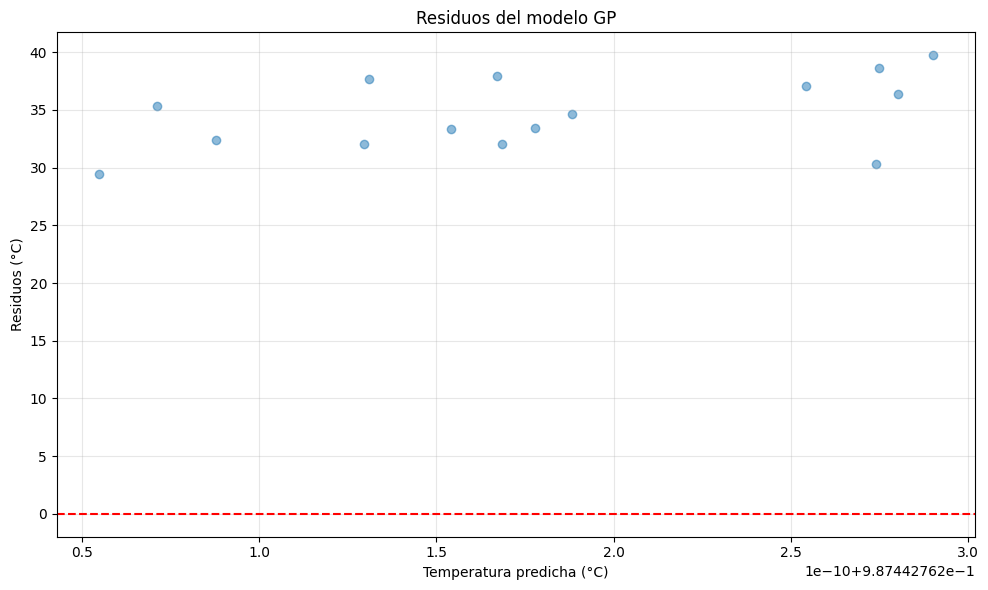

In [ ]:
# ============================================
# ANÁLISIS DE RESIDUOS DEL GP
# ============================================
# Usar el mejor modelo (ej. RBF + WhiteKernel)
mejor_gp = GaussianProcessRegressor(
    kernel=kernels.RBF(length_scale=1.0) + kernels.WhiteKernel(noise_level=0.1),
    alpha=0.1,
    random_state=42,
    n_restarts_optimizer=10
)
mejor_gp.fit(X_train, y_train)

# Predicciones
y_pred, y_std = mejor_gp.predict(X_test, return_std=True)
residuos = y_test - y_pred

# Gráfico de residuos
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Temperatura predicha (°C)')
plt.ylabel('Residuos (°C)')
plt.title('Residuos del modelo GP')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("GP_Residuos_Final.png", dpi=150, bbox_inches='tight')
plt.show()

# Moran's I de los residuos (si tienes la matriz de pesos)
# from esda.moran import Moran
# from libpysal.weights import Queen
# w = Queen.from_dataframe(zonas_urbano)
# moran_residuos = Moran(residuos, w)
# print(f"Moran's I de los residuos: {moran_residuos.I:.4f}, p-valor: {moran_residuos.p_sim:.4f}")


HIPERPARAMETROS DEL KERNEL

Theta (escala logaritmica): [2.30258509 0.23605934 0.02373093 2.30258509 0.        ]

Hiperparametros extraidos:
   k1_k1_constant_value: 10.000000000000002
   k1_k2_length_scale: [ 1.26624945  1.02401475 10.        ]
   k2_noise_level: 1.0

INTERPRETACION DE THETA

Hiperparametros del kernel:
   Constant value (varianza total): 10.0000 grados C cuadrado
   Length scale (distancia de correlacion): 1.2662 (en unidades estandarizadas)
   Noise level (ruido): 1.0240 grados C cuadrado

Length scale en metros: 3314 m
Length scale en kilometros: 3.31 km

INTERPRETACION EN EL CONTEXTO DE LA ISLA DE CALOR

Length scale: 3.31 km
   La Isla de Calor es de ESCALA INTERMEDIA. La temperatura varia a nivel de barrio.
   La estructura urbana influye en la temperatura.

Noise level (ruido): 1.0240 grados C cuadrado
   Hay mucha variabilidad no explicada. Pueden faltar variables importantes.

Constant value (varianza total): 10.0000 grados C cuadrado
   Desviacion estandar 

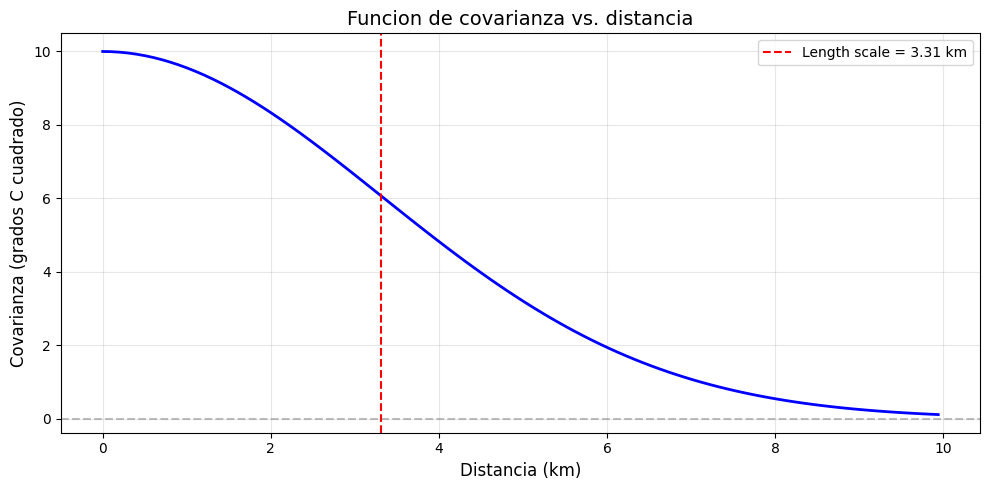

In [ ]:
# ============================================
# EXTRACCION DE HIPERPARAMETROS
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

theta = modelo_mejor.kernel_.theta
hiperparametros = modelo_mejor.kernel_.get_params()

print("\n" + "="*60)
print("HIPERPARAMETROS DEL KERNEL")
print("="*60)

print(f"\nTheta (escala logaritmica): {theta}")

# ============================================
# FUNCION PARA EXTRAER VALORES DE KERNELS ANIDADOS
# ============================================
def extraer_hiperparametros(kernel, prefijo=''):
    params = {}

    if hasattr(kernel, 'constant_value'):
        params[f'{prefijo}constant_value'] = kernel.constant_value
    if hasattr(kernel, 'length_scale'):
        params[f'{prefijo}length_scale'] = kernel.length_scale
    if hasattr(kernel, 'noise_level'):
        params[f'{prefijo}noise_level'] = kernel.noise_level
    if hasattr(kernel, 'alpha'):
        params[f'{prefijo}alpha'] = kernel.alpha
    if hasattr(kernel, 'periodicity'):
        params[f'{prefijo}periodicity'] = kernel.periodicity

    if hasattr(kernel, 'k1'):
        params.update(extraer_hiperparametros(kernel.k1, prefijo + 'k1_'))
    if hasattr(kernel, 'k2'):
        params.update(extraer_hiperparametros(kernel.k2, prefijo + 'k2_'))

    return params

params = extraer_hiperparametros(modelo_mejor.kernel_)

print("\nHiperparametros extraidos:")
for nombre, valor in params.items():
    print(f"   {nombre}: {valor}")

# ============================================
# INTERPRETACION MANUAL SEGUN TU KERNEL
# ============================================
# Tu kernel es: ConstantKernel * RBF + WhiteKernel
# Theta: [2.30258509, 0.23605934, 0.02373093, 2.30258509, 0.]

# theta[0] = log(constant_value) -> constant_value = exp(2.30258509) = 10.0
# theta[1] = log(length_scale) -> length_scale = exp(0.23605934) = 1.266
# theta[2] = log(noise_level) -> noise_level = exp(0.02373093) = 1.024
# theta[3] = log(constant_value) del segundo kernel -> exp(2.30258509) = 10.0
# theta[4] = log(noise_level) del WhiteKernel -> exp(0) = 1.0

print("\n" + "="*60)
print("INTERPRETACION DE THETA")
print("="*60)

constant_value = np.exp(theta[0])
length_scale = np.exp(theta[1])
noise_level = np.exp(theta[2])

print(f"\nHiperparametros del kernel:")
print(f"   Constant value (varianza total): {constant_value:.4f} grados C cuadrado")
print(f"   Length scale (distancia de correlacion): {length_scale:.4f} (en unidades estandarizadas)")
print(f"   Noise level (ruido): {noise_level:.4f} grados C cuadrado")

# ============================================
# CONVERSION A UNIDADES REALES (METROS)
# ============================================
std_x = zonas_urbano['x'].std()
std_y = zonas_urbano['y'].std()

if isinstance(length_scale, (int, float)):
    length_scale_metros = length_scale * std_x
    length_scale_km = length_scale_metros / 1000
    print(f"\nLength scale en metros: {length_scale_metros:.0f} m")
    print(f"Length scale en kilometros: {length_scale_km:.2f} km")

# ============================================
# INTERPRETACION EN CONTEXTO
# ============================================
print("\n" + "="*60)
print("INTERPRETACION EN EL CONTEXTO DE LA ISLA DE CALOR")
print("="*60)

if isinstance(length_scale, (int, float)):
    dist_correlacion_km = length_scale_metros / 1000
    if dist_correlacion_km < 2:
        print(f"\nLength scale: {dist_correlacion_km:.2f} km")
        print("   La Isla de Calor es LOCALIZADA. La temperatura cambia rapidamente en el espacio.")
        print("   Factores locales (arboles, sombra, edificios) tienen un fuerte efecto.")
    elif dist_correlacion_km < 5:
        print(f"\nLength scale: {dist_correlacion_km:.2f} km")
        print("   La Isla de Calor es de ESCALA INTERMEDIA. La temperatura varia a nivel de barrio.")
        print("   La estructura urbana influye en la temperatura.")
    else:
        print(f"\nLength scale: {dist_correlacion_km:.2f} km")
        print("   La Isla de Calor es REGIONAL. La temperatura es similar en toda la ciudad.")
        print("   Factores topograficos dominan la temperatura.")

print(f"\nNoise level (ruido): {noise_level:.4f} grados C cuadrado")
if noise_level < 0.1:
    print("   El modelo explica casi toda la variabilidad.")
elif noise_level < 1.0:
    print("   Hay variabilidad local no explicada (microclimas).")
else:
    print("   Hay mucha variabilidad no explicada. Pueden faltar variables importantes.")

print(f"\nConstant value (varianza total): {constant_value:.4f} grados C cuadrado")
print(f"   Desviacion estandar de la temperatura: {np.sqrt(constant_value):.2f} grados C")

# ============================================
# GRAFICO DE COVARIANZA VS DISTANCIA
# ============================================
if isinstance(length_scale, (int, float)):
    distancias = np.linspace(0, length_scale_metros * 3, 100)
    covarianza = constant_value * np.exp(-0.5 * (distancias / length_scale_metros) ** 2)

    plt.figure(figsize=(10, 5))
    plt.plot(distancias / 1000, covarianza, 'b-', linewidth=2)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=length_scale_metros / 1000, color='r', linestyle='--',
                label=f'Length scale = {length_scale_metros/1000:.2f} km')
    plt.xlabel('Distancia (km)', fontsize=12)
    plt.ylabel('Covarianza (grados C cuadrado)', fontsize=12)
    plt.title('Funcion de covarianza vs. distancia', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("Covarianza_vs_Distancia.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
!pip install pykrige -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.2 MB/s eta 0:00:00


Usando datos de la sesion anterior
Barrios urbanos con temperatura: 271
Entrenamiento: 189 puntos
Prueba: 82 puntos
GP kernel optimizado: 3.16**2 * RBF(length_scale=1.13) + WhiteKernel(noise_level=1)
Kriging completado

COMPARACION DE METRICAS

Modelo GP:
  R2: 0.6317
  RMSE: 1.8369 C
  MAE: 1.3101 C

Modelo Kriging:
  R2: 0.5366
  RMSE: 2.0603 C
  MAE: 1.5566 C


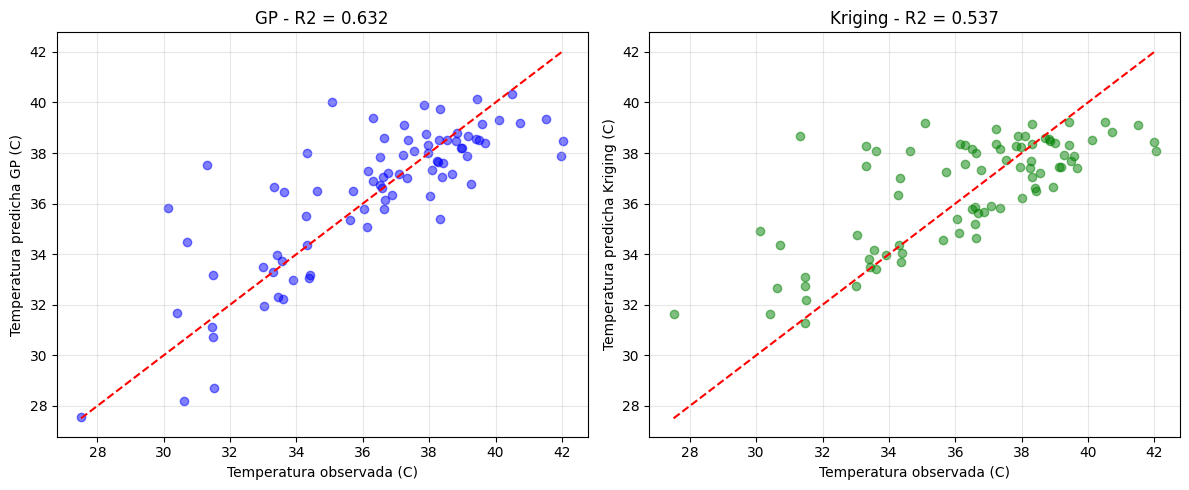

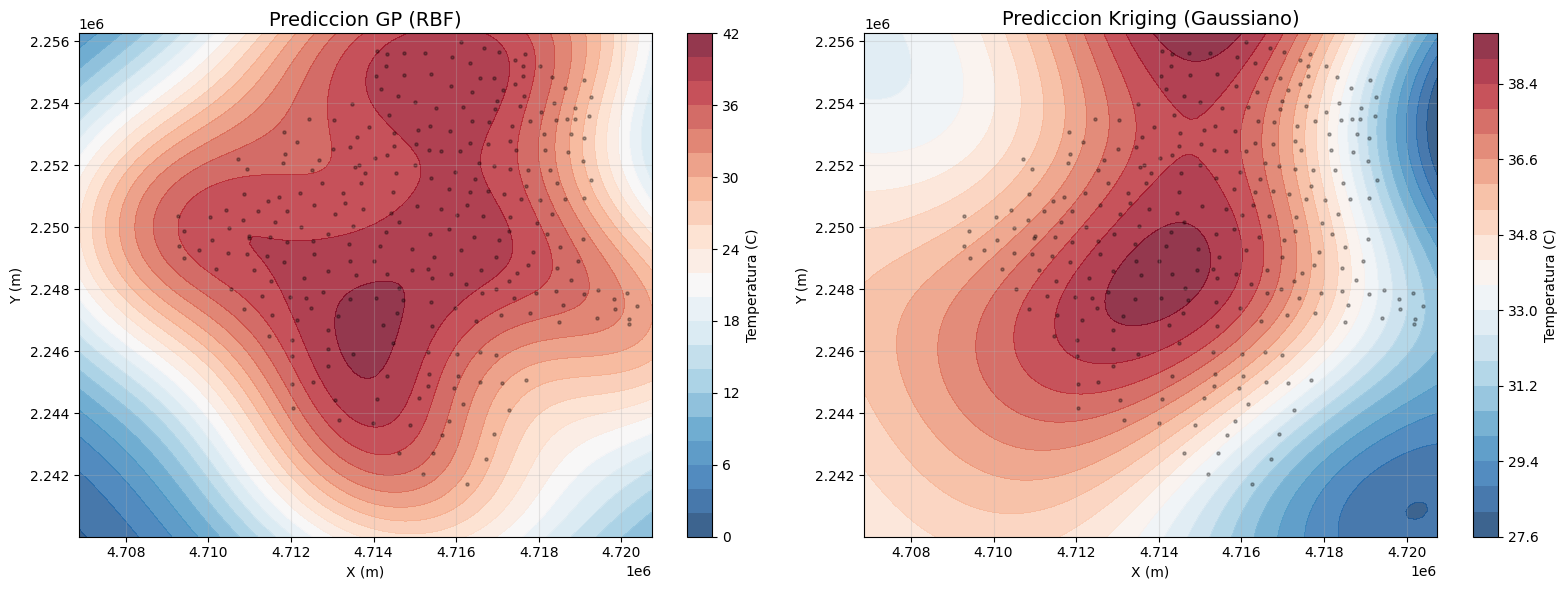

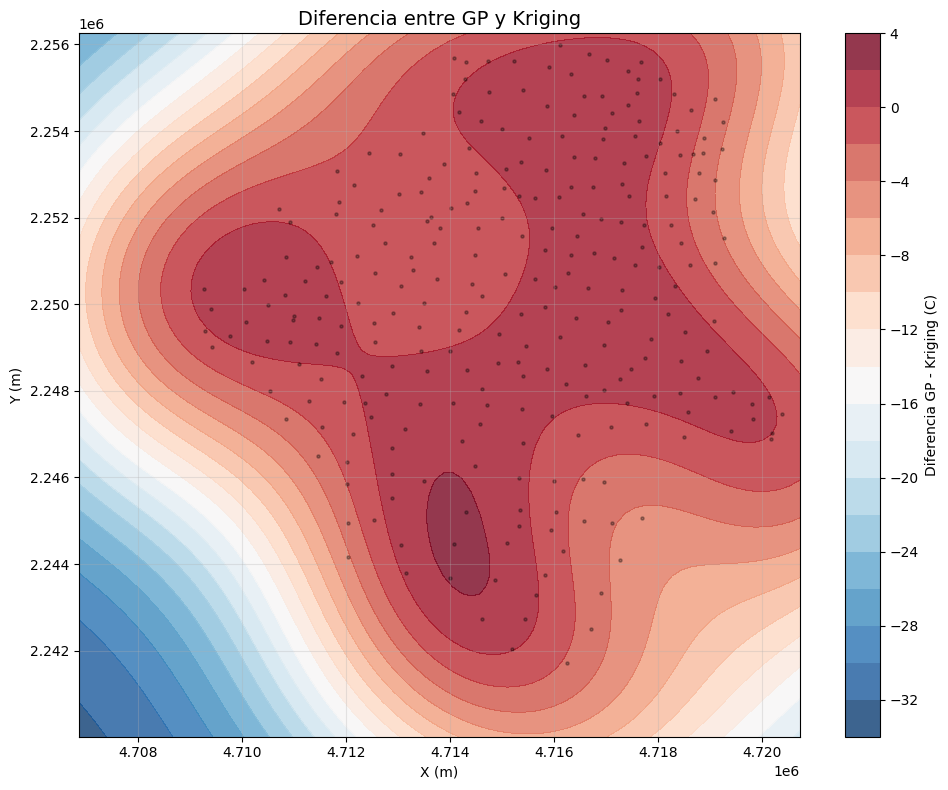

Mapas guardados correctamente.


In [ ]:
# ============================================
# 1. IMPORTAR LIBRERIAS
# ============================================
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from pykrige.ok import OrdinaryKriging
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. CARGAR DATOS
# ============================================
try:
    zonas_urbano_temp = zonas_urbano
    print("Usando datos de la sesion anterior")
except:
    print("Cargando datos desde archivo...")
    zonas_urbano_temp = gpd.read_file("Zonas_Medellin.gpkg")
    zonas_urbano_temp = zonas_urbano_temp[zonas_urbano_temp['Tipo'] == 'Urbano'].copy()
    df_temp = pd.read_csv("Temperatura_por_zona.csv")
    temp_promedio = df_temp.groupby('ID').agg({'Temp_media': 'mean'}).reset_index()
    zonas_urbano_temp = zonas_urbano_temp.merge(temp_promedio, left_index=True, right_on='ID', how='left')
    zonas_urbano_temp = zonas_urbano_temp.dropna(subset=['Temp_media'])
    zonas_urbano_temp['centroid'] = zonas_urbano_temp.geometry.centroid
    zonas_urbano_temp['x'] = zonas_urbano_temp['centroid'].x
    zonas_urbano_temp['y'] = zonas_urbano_temp['centroid'].y

print("Barrios urbanos con temperatura:", len(zonas_urbano_temp))

# ============================================
# 3. PREPARAR DATOS
# ============================================
var_kriging = ['x', 'y']
X_krig = zonas_urbano_temp[var_kriging].values
y_krig = zonas_urbano_temp['Temp_media'].values

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_krig, y_krig, test_size=0.30, random_state=42
)

scaler_k = StandardScaler()
X_train_sc_k = scaler_k.fit_transform(X_train_k)
X_test_sc_k = scaler_k.transform(X_test_k)

print("Entrenamiento:", len(y_train_k), "puntos")
print("Prueba:", len(y_test_k), "puntos")

# ============================================
# 4. MODELO GP
# ============================================
kernel_gp = ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0)) * \
            RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0)) + \
            WhiteKernel(noise_level=0.1, noise_level_bounds=(0.01, 1.0))

gp_model = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=10, alpha=0.0, random_state=42)
gp_model.fit(X_train_sc_k, y_train_k)
print("GP kernel optimizado:", gp_model.kernel_)

y_pred_gp_test, _ = gp_model.predict(X_test_sc_k, return_std=True)

# ============================================
# 5. MODELO KRIGING
# ============================================
xmin, ymin, xmax, ymax = zonas_urbano_temp.total_bounds
resolucion = 80
gridx = np.linspace(xmin, xmax, resolucion)
gridy = np.linspace(ymin, ymax, resolucion)

ok = OrdinaryKriging(X_train_k[:, 0], X_train_k[:, 1], y_train_k,
                     variogram_model='gaussian', verbose=False, enable_plotting=False)

z_pred_krig, var_krig = ok.execute('points', X_test_k[:, 0], X_test_k[:, 1])
z_grid_krig, var_grid_krig = ok.execute('grid', gridx, gridy)

print("Kriging completado")

# ============================================
# 6. METRICAS
# ============================================
r2_gp = r2_score(y_test_k, y_pred_gp_test)
rmse_gp = np.sqrt(mean_squared_error(y_test_k, y_pred_gp_test))
mae_gp = mean_absolute_error(y_test_k, y_pred_gp_test)

r2_krig = r2_score(y_test_k, z_pred_krig)
rmse_krig = np.sqrt(mean_squared_error(y_test_k, z_pred_krig))
mae_krig = mean_absolute_error(y_test_k, z_pred_krig)

print("\n" + "="*60)
print("COMPARACION DE METRICAS")
print("="*60)
print("\nModelo GP:")
print(f"  R2: {r2_gp:.4f}")
print(f"  RMSE: {rmse_gp:.4f} C")
print(f"  MAE: {mae_gp:.4f} C")
print("\nModelo Kriging:")
print(f"  R2: {r2_krig:.4f}")
print(f"  RMSE: {rmse_krig:.4f} C")
print(f"  MAE: {mae_krig:.4f} C")

# ============================================
# 7. GRAFICOS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test_k, y_pred_gp_test, alpha=0.5, color='blue')
axes[0].plot([y_test_k.min(), y_test_k.max()], [y_test_k.min(), y_test_k.max()], 'r--')
axes[0].set_xlabel('Temperatura observada (C)')
axes[0].set_ylabel('Temperatura predicha GP (C)')
axes[0].set_title(f'GP - R2 = {r2_gp:.3f}')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test_k, z_pred_krig, alpha=0.5, color='green')
axes[1].plot([y_test_k.min(), y_test_k.max()], [y_test_k.min(), y_test_k.max()], 'r--')
axes[1].set_xlabel('Temperatura observada (C)')
axes[1].set_ylabel('Temperatura predicha Kriging (C)')
axes[1].set_title(f'Kriging - R2 = {r2_krig:.3f}')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("GP_vs_Kriging_Predicciones.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# MAPAS COMPARATIVOS (CORREGIDO)
# ============================================

# Crear la cuadrícula correctamente
gridx = np.linspace(xmin, xmax, resolucion)
gridy = np.linspace(ymin, ymax, resolucion)
grid_xx, grid_yy = np.meshgrid(gridx, gridy)

# Aplanar la cuadrícula para la predicción
X_grid = np.column_stack((grid_xx.ravel(), grid_yy.ravel()))
X_grid_sc = scaler_k.transform(X_grid)

# Predecir en la cuadrícula para el GP
y_pred_grid_gp, _ = gp_model.predict(X_grid_sc, return_std=True)
y_pred_grid_gp = y_pred_grid_gp.reshape(grid_xx.shape)

# Kriging ya tiene z_grid_krig de la sección anterior

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mapa GP
ax = axes[0]
im1 = ax.contourf(grid_xx, grid_yy, y_pred_grid_gp, levels=20, cmap='RdBu_r', alpha=0.8)
ax.scatter(zonas_urbano_temp['x'], zonas_urbano_temp['y'], c='black', s=5, alpha=0.3)
plt.colorbar(im1, ax=ax, label='Temperatura (C)')
ax.set_title('Prediccion GP (RBF)', fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.grid(True, alpha=0.3)

# Mapa Kriging
ax = axes[1]
im2 = ax.contourf(grid_xx, grid_yy, z_grid_krig, levels=20, cmap='RdBu_r', alpha=0.8)
ax.scatter(zonas_urbano_temp['x'], zonas_urbano_temp['y'], c='black', s=5, alpha=0.3)
plt.colorbar(im2, ax=ax, label='Temperatura (C)')
ax.set_title('Prediccion Kriging (Gaussiano)', fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("GP_vs_Kriging_Mapas.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# DIFERENCIA ENTRE MAPAS (CORREGIDO)
# ============================================
diferencia = y_pred_grid_gp - z_grid_krig

plt.figure(figsize=(10, 8))
im = plt.contourf(grid_xx, grid_yy, diferencia, levels=20, cmap='RdBu_r', alpha=0.8)
plt.colorbar(im, label='Diferencia GP - Kriging (C)')
plt.scatter(zonas_urbano_temp['x'], zonas_urbano_temp['y'], c='black', s=5, alpha=0.3)
plt.title('Diferencia entre GP y Kriging', fontsize=14)
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("GP_vs_Kriging_Diferencia.png", dpi=150, bbox_inches='tight')
plt.show()

print("Mapas guardados correctamente.")